# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of another two synthetic data generation models:
1. **CTAB GAN Plus** - Conditional Tabular GAN plus
2. **WGAN-GP** - Wassertian GAN with gradiant penalty

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data

In [3]:
import pandas as pd
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets

# metadata
print(covertype.metadata)

# variable information
print(covertype.variables)

# combine to original data
data = pd.concat([X, y], axis=1)

{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Build full table (features + target) from X, y loaded above
covertype_data = pd.concat([X, y], axis=1)

# Subsample to 1000 rows for faster training
SAMPLE_SIZE = 1000
if len(covertype_data) > SAMPLE_SIZE:
    covertype_data = covertype_data.sample(n=SAMPLE_SIZE, random_state=42)

# SDV metadata
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(covertype_data)

print(f"Data shape: {covertype_data.shape}")
print(f"Columns: {list(covertype_data.columns)}")

Data shape: (1000, 55)
Columns: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Cover_Type']


# 1. Univariate Analysis

In [9]:
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
import pandas as pd

# Number of synthetic rows to generate per model
n_samples = 1000

# Define models
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(covertype_data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=covertype_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data=covertype_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 55/55 [00:00<00:00, 2523.98it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 222.26it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1655.83it/s]|
Column Shapes Score: 95.76%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:04<00:00, 359.60it/s]|
Column Pair Trends Score: 76.63%

Overall Score (Average): 86.19%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 55/55 [00:00<00:00, 2085.70it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 251.43it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1711.50it/s]|
Column Shapes Score: 94.15%



,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.925026
1,TVAE,1.0,0.881179
2,CTGAN,1.0,0.861948
3,CopulaGAN,1.0,0.854850



Best model by quality score: GaussianCopula


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,3206,300,7,284,82,3075,229,241,136,3883,...,0,0,0,0,0,0,0,0,0,2
1,3112,339,10,666,72,3309,183,219,165,1344,...,0,0,0,0,0,0,0,1,0,2
2,3105,331,33,373,232,931,203,232,180,307,...,0,0,0,0,0,0,0,1,0,2
3,2422,150,17,230,-26,751,214,204,137,816,...,0,0,0,0,0,0,0,1,1,6
4,2945,53,11,387,97,654,239,208,103,2421,...,0,0,0,0,0,0,1,1,0,2


### 1.1.  Kolmogorov-Smirnov (K-S) test

Target standardized as 'Cover_Type'

--- Evaluating CTGAN ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 700.89it/s]|
Column Shapes Score: 95.76%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:08<00:00, 170.63it/s]|
Column Pair Trends Score: 76.63%

Overall Score (Average): 86.19%


--- Evaluating CopulaGAN ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 639.48it/s]|
Column Shapes Score: 94.15%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:06<00:00, 218.43it/s]|
Column Pair Trends Score: 76.82%

Overall Score (Average): 85.48%


--- Evaluating TVAE ---
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1002.18it/s]|
Column Shapes Score: 95.44%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:07<00:00, 190.96it/s]|
Column Pair Trends Score: 80.79%

Overall Score (Average): 88.12%


--- Evaluating GaussianCopula

,Model,Avg_Column_Score,Cover_Type_Score
0,CTGAN,0.957600,0.809
1,CopulaGAN,0.941455,0.891
2,TVAE,0.954436,0.847
3,GaussianCopula,0.982891,0.983


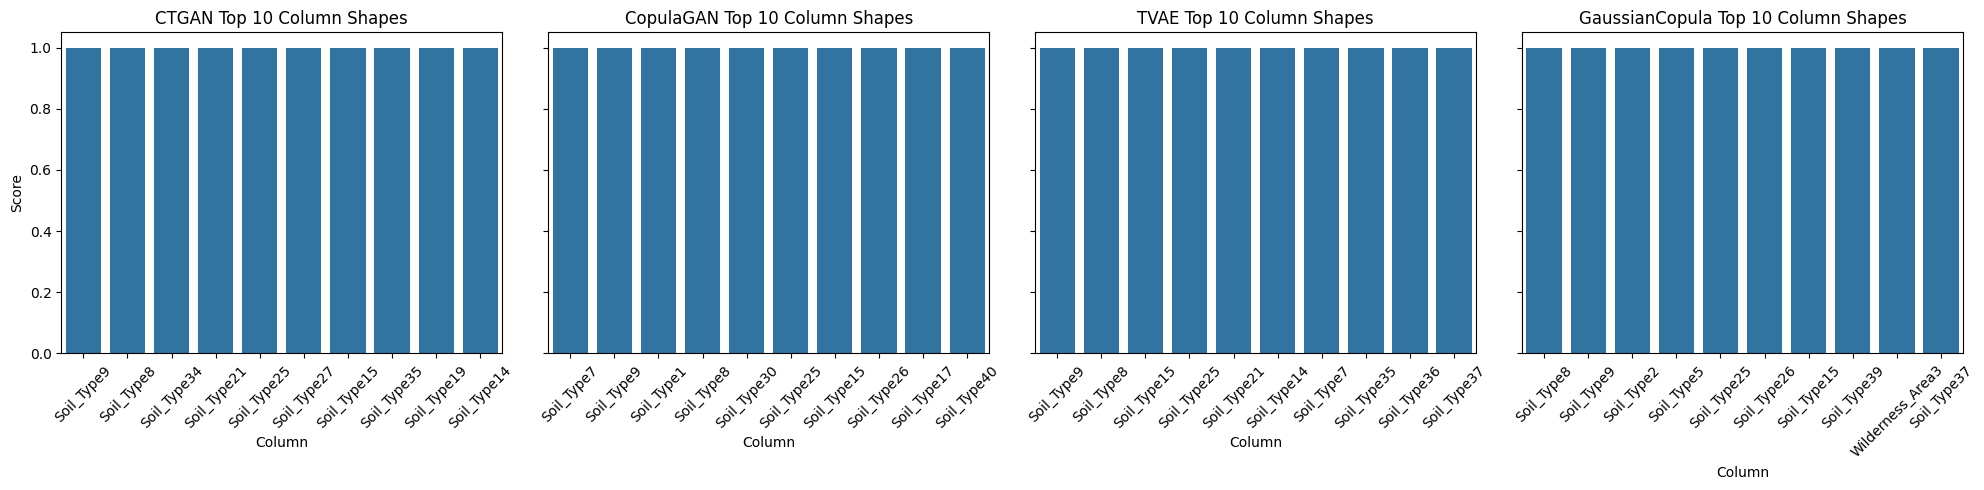

In [28]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sdv.metadata import SingleTableMetadata

# -----------------------------
# 1. Verification and Setup
# -----------------------------
target_col = "Cover_Type"
real_data = covertype_data.copy() if 'covertype_data' in globals() else data.sample(1000).copy()

# Ensure synthetic_outputs exists (Map from previous training if necessary)
if 'synthetic_outputs' not in globals():
    if 'synthetic_datasets' in globals():
        synthetic_outputs = synthetic_datasets.copy()
    else:
        raise NameError("No synthetic datasets found. Please run the model training cell first.")

# Standardize synthetic outputs
for model_name in list(synthetic_outputs.keys()):
    synth_df = synthetic_outputs[model_name].copy()
    if target_col not in synth_df.columns:
        synth_old_target_col = synth_df.columns[-1]
        synth_df = synth_df.rename(columns={synth_old_target_col: target_col})
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()
    synthetic_outputs[model_name] = synth_df

print(f"Target standardized as '{target_col}'")

# Detect metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)
metadata.update_column(column_name=target_col, sdtype="categorical")

# Update: Including CopulaGAN in the list of models to evaluate
model_order = [m for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"] if m in synthetic_outputs]
column_shape_details = {}
summary_rows = {}

# -----------------------------
# 2. Generate QualityReport for each model
# -----------------------------
for model_name in model_order:
    print(f"\n--- Evaluating {model_name} ---")
    qr = QualityReport()
    synthetic_data = synthetic_outputs[model_name]

    qr.generate(real_data, synthetic_data, metadata.to_dict())

    details = qr.get_details("Column Shapes")
    score_col = "Score" if "Score" in details.columns else "Quality Score"
    column_shape_details[model_name] = details.sort_values(score_col, ascending=False)

    summary_rows[model_name] = {
        "Model": model_name,
        "Avg_Column_Score": float(details[score_col].mean()),
        f"{target_col}_Score": details.loc[details["Column"] == target_col, score_col].iloc[0]
    }

# -----------------------------
# 3. Visualization
# -----------------------------
summary_df = pd.DataFrame(summary_rows.values())
display(summary_df)

fig, axes = plt.subplots(1, len(model_order), figsize=(20, 5), sharey=True)
if len(model_order) == 1: axes = [axes]

for i, model_name in enumerate(model_order):
    sns.barplot(x="Column", y="Score", data=column_shape_details[model_name].head(10), ax=axes[i])
    axes[i].set_title(f"{model_name} Top 10 Column Shapes")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 1.2. Jensen–Shannon divergence

In [29]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

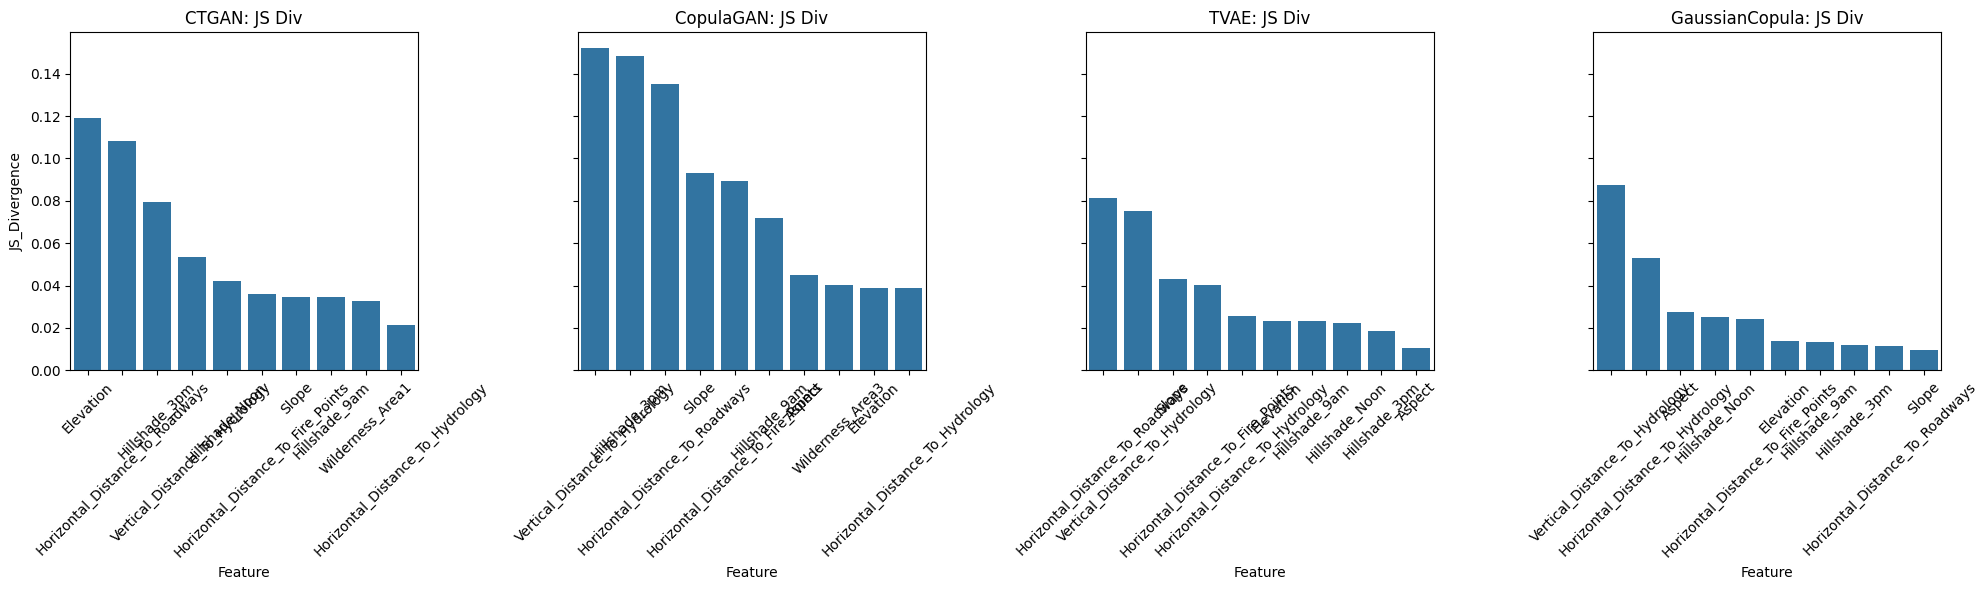

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()
    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)
    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df, synth_df, bins=30, normalize=True):
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])
    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]
        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)
        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": js_div})
    return pd.DataFrame(results).sort_values("JS_Divergence")

# UPDATED: Use all 4 models
real_df_js = covertype_data.drop(columns=[target_col])
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

valid_models = [m for m in model_order if m in synthetic_outputs]
fig, axes = plt.subplots(1, len(valid_models), figsize=(20, 6), sharey=True)
if len(valid_models) == 1: axes = [axes]

for i, model_name in enumerate(valid_models):
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    js_df = compute_js_divergence(real_df_js, synth_df, bins="fd", normalize=True).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

    sns.barplot(x="Feature", y="JS_Divergence", data=js_df.head(10), ax=axes[i])
    axes[i].set_title(f"{model_name}: JS Div")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 1.3 Wasserstein Distance


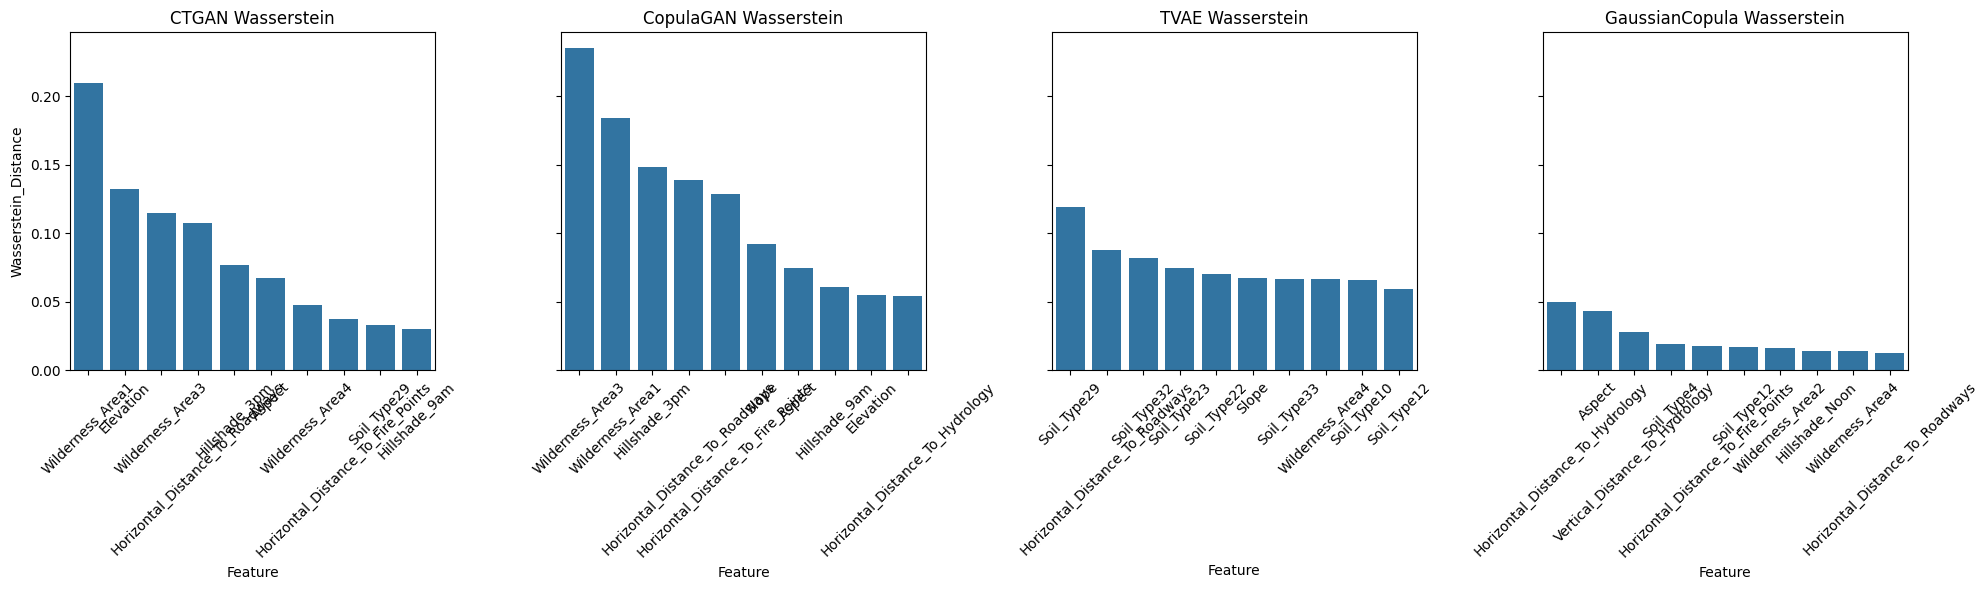

In [31]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler

# UPDATED: Use all 4 models
real_df_w = covertype_data.drop(columns=[target_col])
numeric_cols = real_df_w.select_dtypes(include=[np.number]).columns.tolist()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(scaler.fit_transform(real_df_w[numeric_cols]), columns=numeric_cols)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
valid_models = [m for m in model_order if m in synthetic_outputs]

fig, axes = plt.subplots(1, len(valid_models), figsize=(20, 6), sharey=True)
if len(valid_models) == 1: axes = [axes]

for i, model_name in enumerate(valid_models):
    synth_numeric = synthetic_outputs[model_name][numeric_cols].fillna(real_df_w[numeric_cols].median())
    synthetic_scaled = pd.DataFrame(scaler.transform(synth_numeric), columns=numeric_cols)

    dists = []
    for col in numeric_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append({"Feature": col, "Wasserstein_Distance": dist})

    dist_df = pd.DataFrame(dists).sort_values("Wasserstein_Distance", ascending=False)
    sns.barplot(x="Feature", y="Wasserstein_Distance", data=dist_df.head(10), ax=axes[i])
    axes[i].set_title(f"{model_name} Wasserstein")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [18]:
pip install gower

In [32]:
import gower
# UPDATED: Use all 4 models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
valid_models = [m for m in model_order if m in synthetic_outputs]

gower_results = []
for model_name in valid_models:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    Xr, Xs, _ = prepare_for_gower(X_real, X_synth)

    g_matrix = 1 - gower.gower_matrix(Xr, Xs)
    avg_cross = np.mean(g_matrix)

    gower_results.append({"Model": model_name, "Avg_Cross_Similarity": avg_cross})

gower_summary = pd.DataFrame(gower_results)
display(gower_summary)

,Model,Avg_Cross_Similarity
0,CTGAN,0.902477
1,CopulaGAN,0.901364
2,TVAE,0.924451
3,GaussianCopula,0.906039


### 2. Multivariate Correlation Analysis
We will now visualize the correlation matrices for the real data and each synthetic model to check how well column pair trends are preserved.

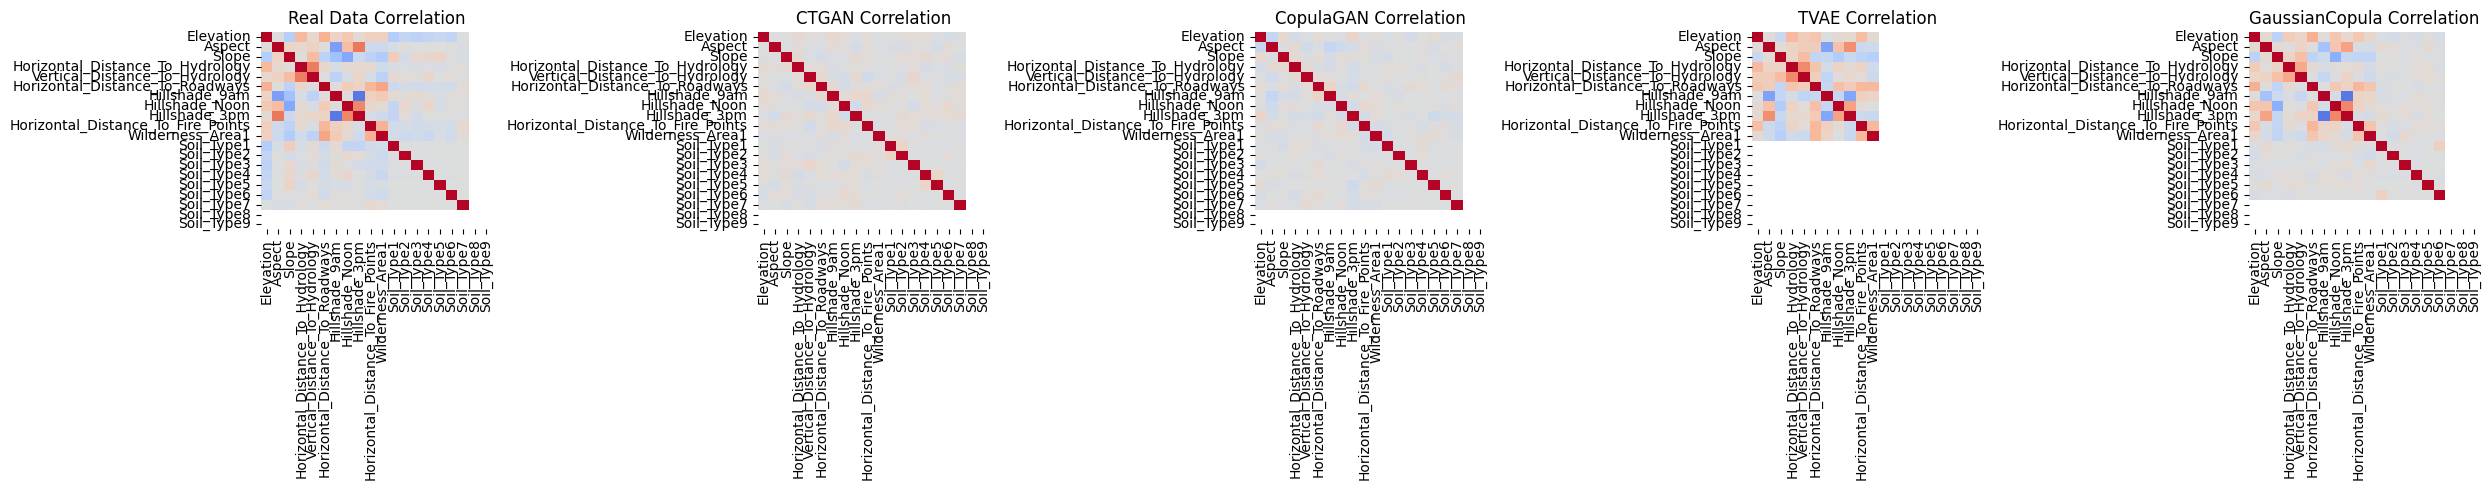

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_correlation_comparison(real_df, synthetic_outputs, model_names, target_col):
    # Prepare numeric data for a manageable heatmap (Top 15 features by variance or just numeric)
    real_numeric = real_df.select_dtypes(include=[np.number])
    # Using a subset of columns if the dataset is too wide for clear heatmaps
    cols_to_plot = real_numeric.columns[:20]
    real_corr = real_numeric[cols_to_plot].corr()

    n_models = len(model_names)
    fig, axes = plt.subplots(1, n_models + 1, figsize=(5 * (n_models + 1), 5))

    # Plot Real Data Correlation
    sns.heatmap(real_corr, cmap='coolwarm', center=0, ax=axes[0], cbar=False)
    axes[0].set_title("Real Data Correlation")

    for i, model_name in enumerate(model_names):
        synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors='ignore')
        synth_numeric = synth_df[cols_to_plot].select_dtypes(include=[np.number])
        synth_corr = synth_numeric.corr()

        # Plot Model Correlation
        sns.heatmap(synth_corr, cmap='coolwarm', center=0, ax=axes[i+1], cbar=False)
        axes[i+1].set_title(f"{model_name} Correlation")

    plt.tight_layout()
    plt.show()

# Filter for existing models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
valid_models = [m for m in model_order if m in synthetic_outputs]

# Drop target for correlation view
real_df_corr = covertype_data.drop(columns=[target_col])

plot_correlation_comparison(real_df_corr, synthetic_outputs, valid_models, target_col)

### 2. Multivariate Correlation Analysis
We will now visualize the correlation matrices for the real data and each synthetic model to check how well column pair trends are preserved.

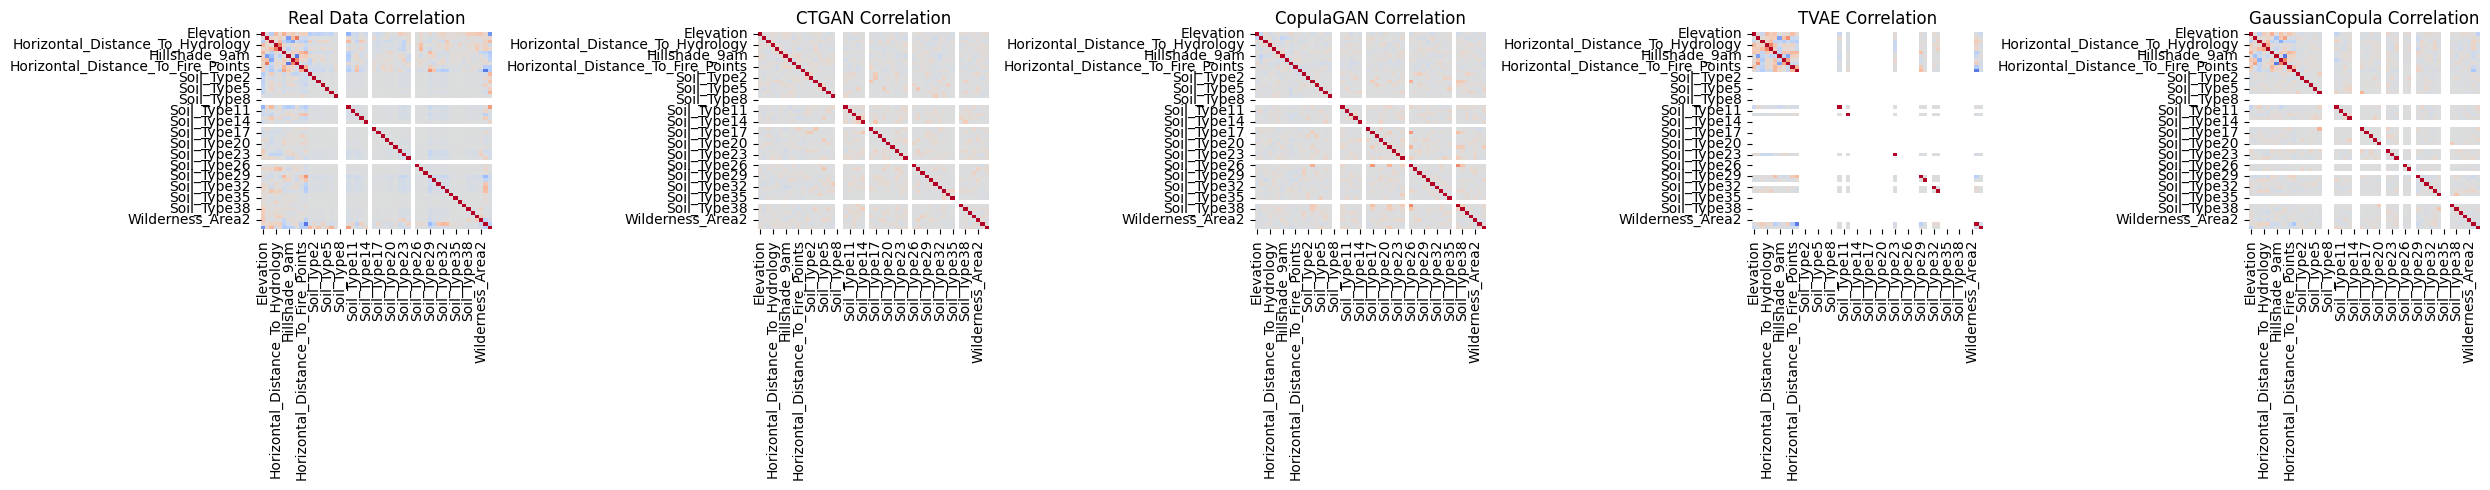

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_correlation_comparison(real_df, synthetic_outputs, model_names, target_col):
    # Prepare numeric data
    real_numeric = real_df.select_dtypes(include=[np.number])
    real_corr = real_numeric.corr()

    n_models = len(model_names)
    fig, axes = plt.subplots(1, n_models + 1, figsize=(5 * (n_models + 1), 5))

    # Plot Real Data Correlation
    sns.heatmap(real_corr, cmap='coolwarm', center=0, ax=axes[0], cbar=False)
    axes[0].set_title("Real Data Correlation")

    for i, model_name in enumerate(model_names):
        synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors='ignore')
        synth_numeric = synth_df.select_dtypes(include=[np.number])
        synth_corr = synth_numeric.corr()

        # Plot Model Correlation
        sns.heatmap(synth_corr, cmap='coolwarm', center=0, ax=axes[i+1], cbar=False)
        axes[i+1].set_title(f"{model_name} Correlation")

    plt.tight_layout()
    plt.show()

# Filter for existing models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
valid_models = [m for m in model_order if m in synthetic_outputs]

# Drop target for correlation view
real_df_corr = covertype_data.drop(columns=[target_col])

plot_correlation_comparison(real_df_corr, synthetic_outputs, valid_models, target_col)

### 3. Privacy Assessment: Distance to Closest Record (DCR)
To check for data leakage or 'memorization', we calculate the Euclidean distance between each synthetic record and its nearest neighbor in the real dataset. A DCR of 0 would indicate an exact replica of a training record.

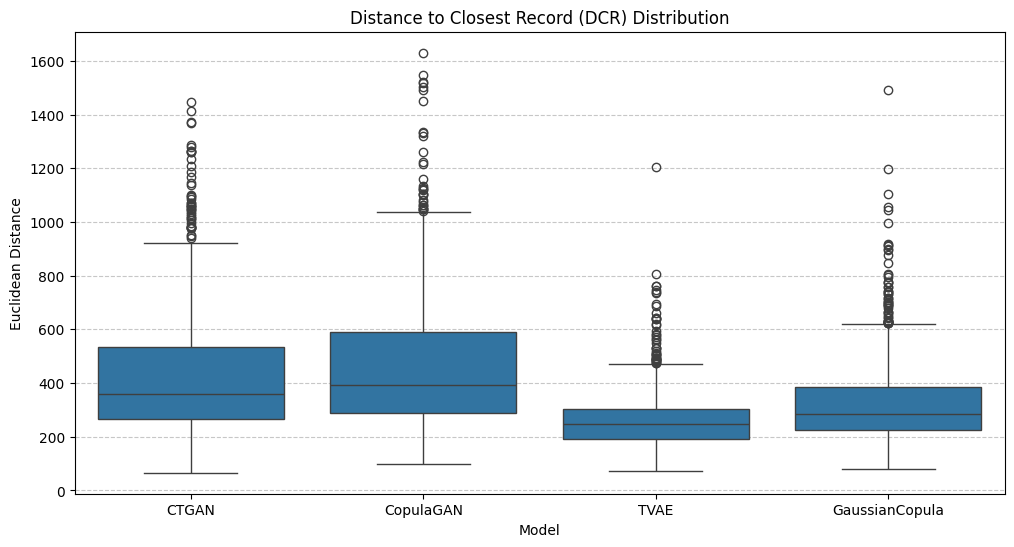

Number of identical or near-identical records detected:


,Model,Exact_Matches


In [35]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def calculate_dcr(real_df, synth_df, model_name):
    # Use numeric columns for distance calculation
    numeric_cols = real_df.select_dtypes(include=[np.number]).columns

    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(real_df[numeric_cols])

    distances, _ = nn.kneighbors(synth_df[numeric_cols])
    return distances.flatten()

dcr_data = []
for name in valid_models:
    distances = calculate_dcr(covertype_data, synthetic_outputs[name], name)
    for d in distances:
        dcr_data.append({'Model': name, 'DCR': d})

dcr_df = pd.DataFrame(dcr_data)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Model', y='DCR', data=dcr_df)
plt.title('Distance to Closest Record (DCR) Distribution')
plt.ylabel('Euclidean Distance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Summary of potential leaks (DCR very close to 0)
leak_summary = dcr_df[dcr_df['DCR'] < 1e-5].groupby('Model').size().reset_index(name='Exact_Matches')
print("Number of identical or near-identical records detected:")
display(leak_summary)

### 1.5 t-SNE Visualization


Using 54 numeric features for t-SNE: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']


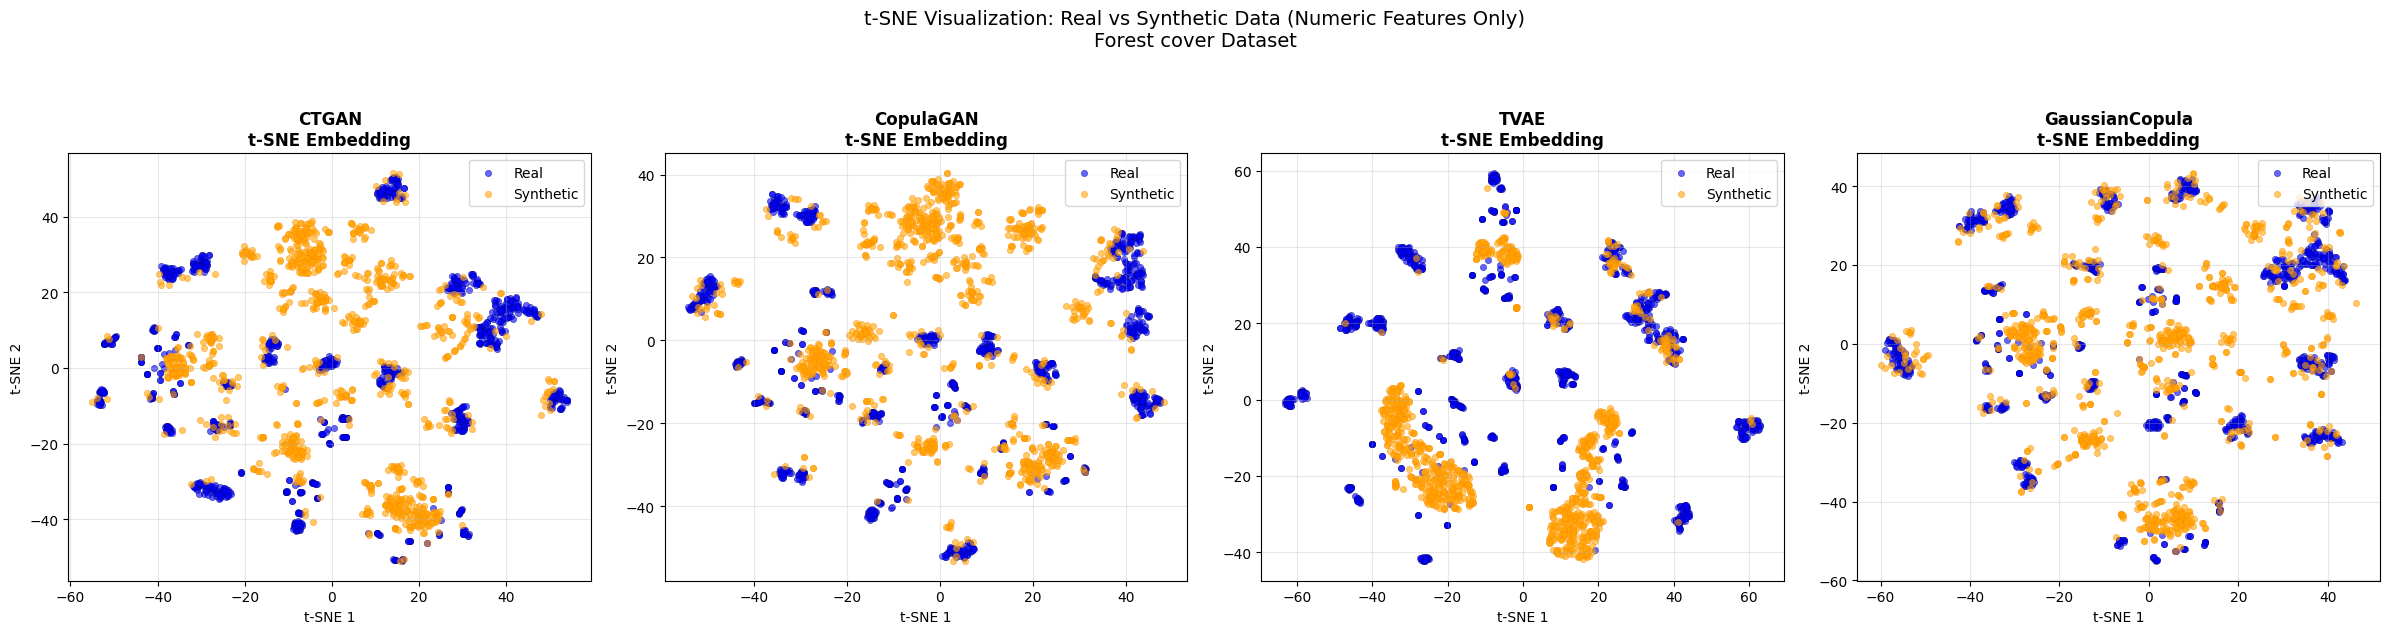

In [36]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fix: Use the available covertype_data variable
data = covertype_data.copy()
target_col = 'Cover_Type'

# Adjust model order to match trained models - including CopulaGAN
model_order = [m for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"] if m in synthetic_outputs]

# Remove target and separate numeric/categorical
X_real = data.drop(columns=[target_col], errors="ignore")

# USE ONLY NUMERIC COLUMNS
numeric_cols = X_real.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(numeric_cols)} numeric features for t-SNE: {numeric_cols}")

X_real_numeric = X_real[numeric_cols].copy()

# Scale numeric data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(X_real_numeric),
    columns=numeric_cols,
    index=X_real_numeric.index
)

# Create t-SNE plots
fig, axes = plt.subplots(1, len(model_order), figsize=(24, 6))
if len(model_order) == 1: axes = [axes]

for i, model_name in enumerate(model_order):
    ax = axes[i]

    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    synth_numeric = synth_df[numeric_cols].copy()

    # Clean synthetic numeric data
    synth_numeric = synth_numeric.replace([np.inf, -np.inf], np.nan)
    synth_numeric = synth_numeric.fillna(synth_numeric.median())

    # Scale synthetic data using real scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )

    # Combine real + synthetic
    combined = np.vstack([
        real_scaled.values,
        synthetic_scaled.values
    ])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(combined)

    # Plot
    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=20, label="Real",
        edgecolors='darkblue', linewidth=0.5
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=20, label="Synthetic",
        edgecolors='darkorange', linewidth=0.5
    )

    ax.set_title(f"{model_name}\nt-SNE Embedding", fontsize=12, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("t-SNE Visualization: Real vs Synthetic Data (Numeric Features Only)\nForest cover Dataset",
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 1.6 Maximum Mean Discrepancy (MMD)
Maximum Mean Discrepancy is a kernel-based statistical test used to determine whether two samples are drawn from the same distribution. A lower MMD score indicates that the synthetic data distribution is closer to the real data distribution.

In [38]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

# Configuration
target_col = 'Cover_Type'
# Updated to include CopulaGAN
model_order = [m for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"] if m in synthetic_outputs]

# Prepare real features (numeric only)
real_features = covertype_data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()

    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})
    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Display comparison table
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.0176
CopulaGAN - MMD score: 0.0310
TVAE - MMD score: 0.0568
GaussianCopula - MMD score: 0.0024

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.002448
1,CTGAN,0.017627
2,CopulaGAN,0.031029
3,TVAE,0.056792


### 1.7 Cosine Similarity


In [39]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# UPDATED: Included CopulaGAN in the model order
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
data = covertype_data.copy()
target_col = 'Cover_Type'

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

similarity_results = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        continue

    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()

    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())

    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0003
Maximum cosine similarity: 0.9908

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0046
Maximum cosine similarity: 0.9946

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0091
Maximum cosine similarity: 0.9838

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0021
Maximum cosine similarity: 0.9898

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.009101,0.983779
1,CopulaGAN,0.004608,0.994626
2,GaussianCopula,0.002111,0.989847
3,CTGAN,0.000336,0.990836


### 1.8 Nearest Neighbors Privacy Check
This metric measures the distance from each synthetic sample to the closest real sample. Higher average distances typically suggest better privacy protection, while very small distances may indicate that the model is memorizing training examples.

In [40]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Configuration
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
data = covertype_data.copy()
target_col = 'Cover_Type'

# Prepare real features (numeric only)
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = real_features[numeric_cols].copy()

privacy_rows = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        continue

    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = synth_df[numeric_cols].copy()

    # Clean synthetic data
    X_synth = X_synth.replace([np.inf, -np.inf], np.nan)
    X_synth = X_synth.fillna(X_synth.median())

    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Nearest Neighbor Search: Synthetic samples to Real samples
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_dist = np.mean(distances)
    min_dist = np.min(distances)
    p5_dist = np.percentile(distances, 5)

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_dist,
        "Min_NN_Distance": min_dist,
        "5th_Percentile_Distance": p5_dist
    })

    print(f"{model_name} - Avg NN Distance: {avg_dist:.4f}")

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values("Avg_NN_Distance", ascending=False)

print("\nPrivacy summary (Higher Avg distance generally means better privacy):")
display(privacy_summary_df)

CTGAN - Avg NN Distance: 4.8219
CopulaGAN - Avg NN Distance: 4.9035
TVAE - Avg NN Distance: 3.2543
GaussianCopula - Avg NN Distance: 3.9999

Privacy summary (Higher Avg distance generally means better privacy):


,Model,Avg_NN_Distance,Min_NN_Distance,5th_Percentile_Distance
1,CopulaGAN,4.903505,1.607414,2.837898
0,CTGAN,4.821889,1.523894,2.821172
3,GaussianCopula,3.999924,1.009014,1.813220
2,TVAE,3.254261,0.863514,1.544428


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,40.198757,17.072214,19.948572
1,CopulaGAN,72.636275,26.269562,27.780323
2,TVAE,76.959918,100.000000,74.108926
3,GaussianCopula,26.610770,12.047101,20.321263


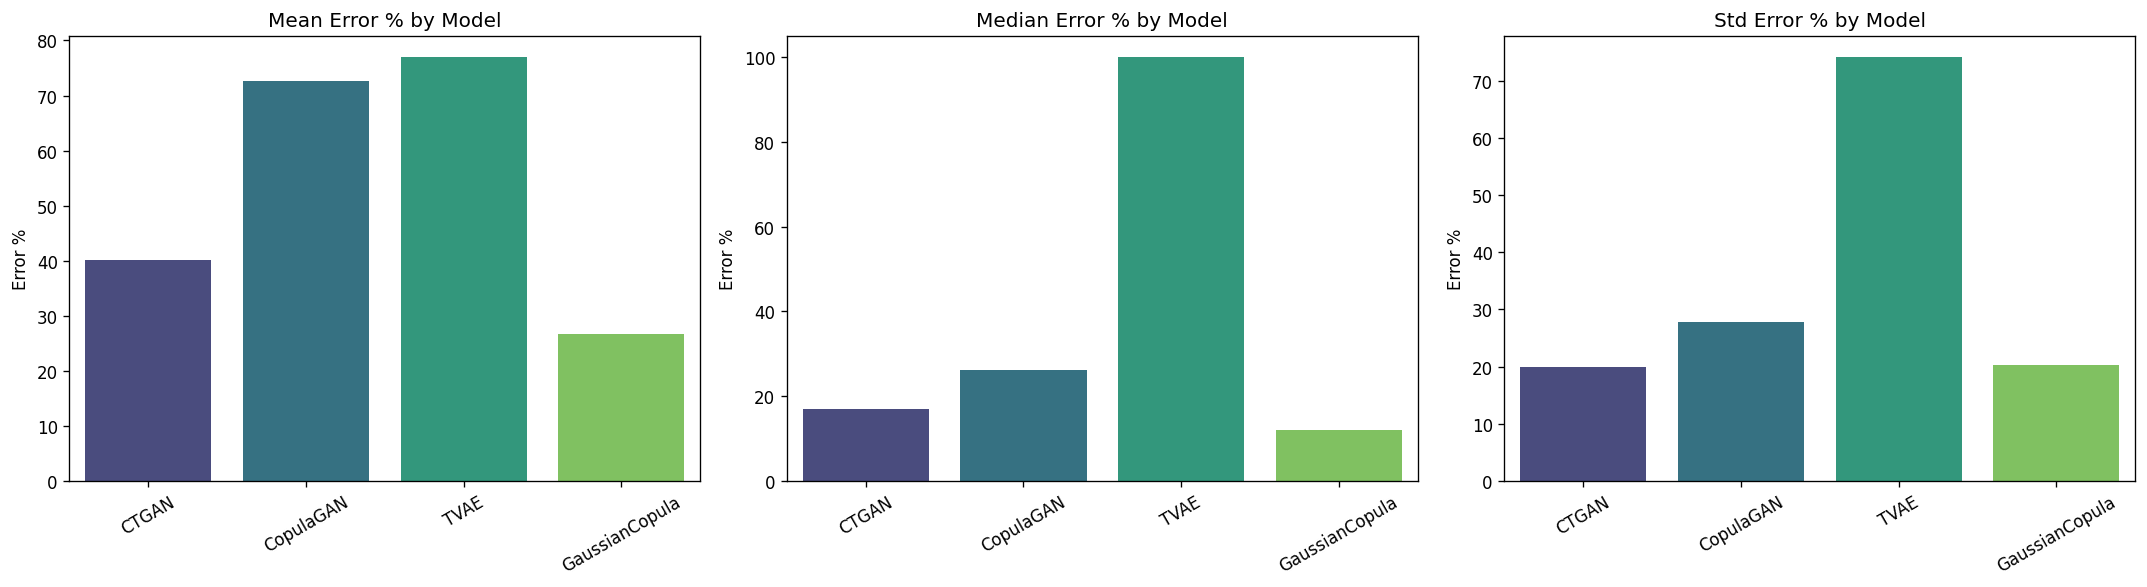

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to include all four GAN/Synthetic models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

data = covertype_data.copy()
data = data.loc[:, ~data.columns.duplicated()].copy()

target_col = "Cover_Type"

real_df = data.copy()
real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    if model_name not in synthetic_outputs:
        continue

    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    common_num_cols = [
        col for col in num_cols
        if col in synth_df.columns
    ]

    real_num = real_df[common_num_cols].copy()
    synth_num = synth_df[common_num_cols].copy()

    real_num = real_num.apply(pd.to_numeric, errors="coerce")
    synth_num = synth_num.apply(pd.to_numeric, errors="coerce")

    real_num = real_num.fillna(real_num.median(numeric_only=True))
    synth_num = synth_num.fillna(synth_num.median(numeric_only=True))

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (
        np.abs(synth_means - real_means)
        / real_means.replace(0, np.nan).abs()
    ) * 100

    std_error_pct = (
        np.abs(synth_stds - real_stds)
        / real_stds.replace(0, np.nan).abs()
    ) * 100

    feature_error_df = pd.DataFrame({
        "Feature": common_num_cols,
        "Mean_Error_%": [mean_error_pct.get(col, np.nan) for col in common_num_cols],
        "Std_Error_%": [std_error_pct.get(col, np.nan) for col in common_num_cols]
    }).replace([np.inf, -np.inf], np.nan)

    summary_rows.append({
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    })

    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
for i, metric in enumerate(metrics):
    sns.barplot(data=summary_df, x="Model", y=metric, ax=axes[i], palette="viridis", hue="Model", legend=False)
    axes[i].set_title(f"{metric} by Model")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Error %")

plt.tight_layout()
plt.show()

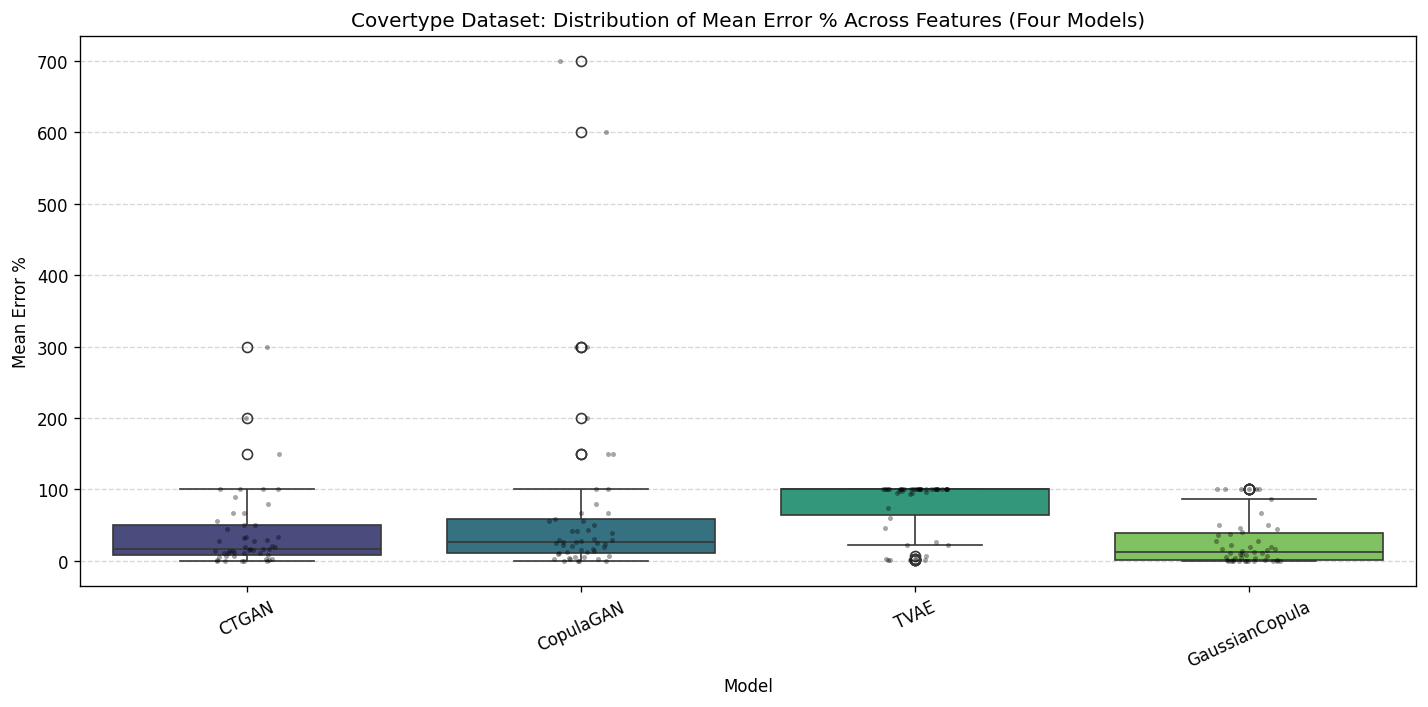

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to include all four models from the previous training run
model_list = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

plot_rows = [
    feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
    for m in model_list
    if m in feature_error_by_model and not feature_error_by_model[m].empty
]

if plot_rows:
    dist_df = (
        pd.concat(plot_rows, ignore_index=True)
        .replace([float("inf"), float("-inf")], pd.NA)
        .dropna(subset=["Mean_Error_%"])
    )

    plt.figure(figsize=(12, 6), dpi=120)
    sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis", hue="Model", legend=False)
    sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)

    plt.title("Covertype Dataset: Distribution of Mean Error % Across Features (Four Models)")
    plt.xlabel("Model")
    plt.ylabel("Mean Error %")
    plt.xticks(rotation=25)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No feature error results available. Run the previous error-summary cell (cell NemKdgKAaie6) first.")

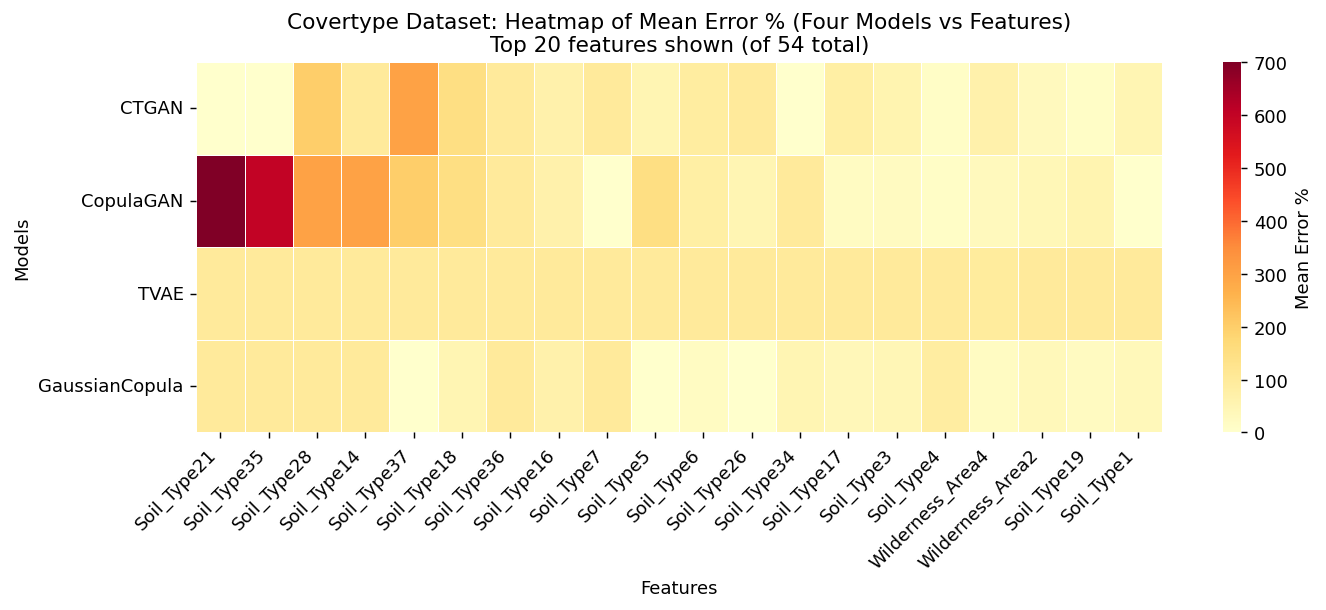

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to include all four models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_rows = {}

for m in model_order:
    if m in feature_error_by_model and not feature_error_by_model[m].empty:
        temp = feature_error_by_model[m][["Feature", "Mean_Error_%"]].copy()
        temp = temp.drop_duplicates(subset="Feature", keep="first")
        temp["Mean_Error_%"] = pd.to_numeric(temp["Mean_Error_%"], errors="coerce")
        heatmap_rows[m] = temp.set_index("Feature")["Mean_Error_%"]

if heatmap_rows:
    heatmap_df = pd.DataFrame(heatmap_rows).T
    heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

    max_features = 20

    if heatmap_df.shape[1] > max_features:
        top_features = (
            heatmap_df.mean(axis=0, skipna=True)
            .sort_values(ascending=False)
            .head(max_features)
            .index
        )
        heatmap_plot_df = heatmap_df[top_features]
        truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
    else:
        heatmap_plot_df = heatmap_df.copy()
        truncated_note = "All features shown"

    def truncate_label(s, max_len=18):
        s = str(s)
        return s if len(s) <= max_len else s[:max_len - 1] + "..."

    display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

    plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)

    sns.heatmap(
        heatmap_plot_df,
        cmap="YlOrRd",
        annot=False,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Mean Error %"}
    )

    plt.title(f"Covertype Dataset: Heatmap of Mean Error % (Four Models vs Features)\n{truncated_note}")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No feature error results available. Run the previous error-summary cell (cell NemKdgKAaie6) first.")

### 1.9 Statistical Moments Error Summary
This section aggregates the column-wise mean and standard deviation errors into a single model-level comparison. Lower error percentages indicate better preservation of the original data's statistical distribution.

Average Statistical Error by Model (Lower is Better):


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,40.198757,17.072214,19.948572
1,CopulaGAN,72.636275,26.269562,27.780323
2,TVAE,76.959918,100.000000,74.108926
3,GaussianCopula,26.610770,12.047101,20.321263


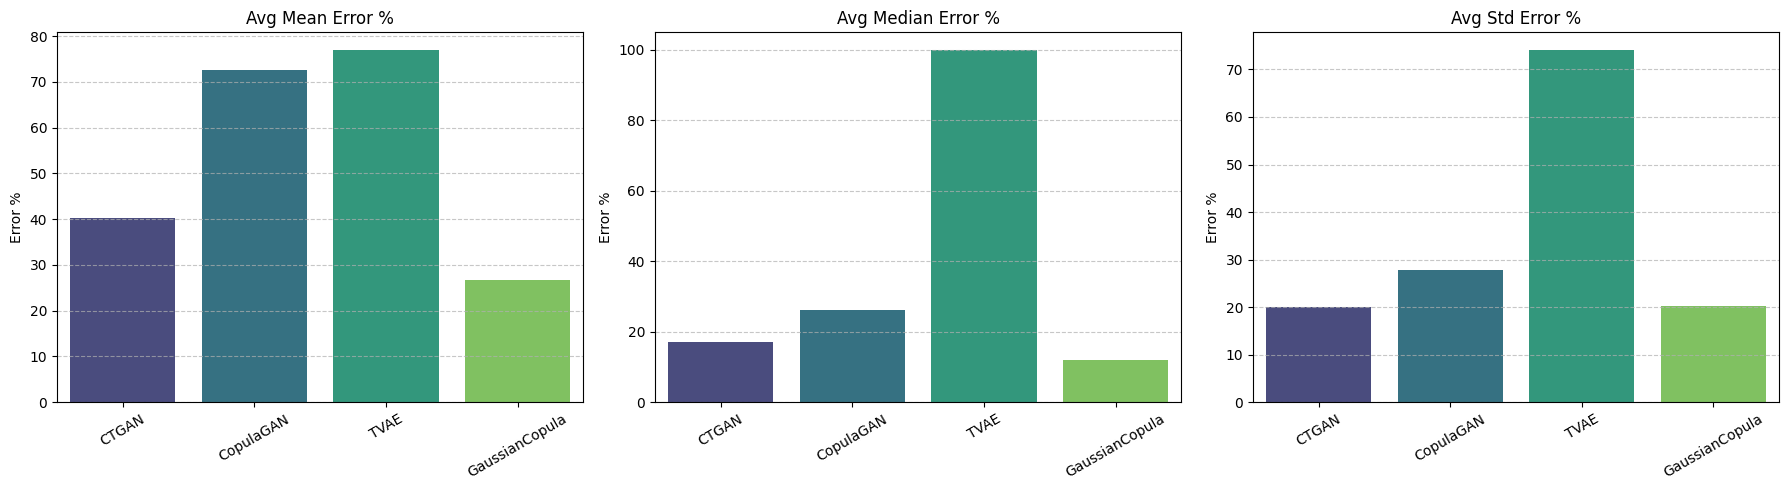

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare summary data from the feature_error_by_model dictionary created in NemKdgKAaie6
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
summary_rows = []

for model_name in model_order:
    if model_name in feature_error_by_model and not feature_error_by_model[model_name].empty:
        df = feature_error_by_model[model_name]
        summary_rows.append({
            "Model": model_name,
            "Mean Error %": df["Mean_Error_%"].mean(skipna=True),
            "Median Error %": df["Mean_Error_%"].median(skipna=True),
            "Std Error %": df["Std_Error_%"].mean(skipna=True)
        })

summary_df = pd.DataFrame(summary_rows)

print("Average Statistical Error by Model (Lower is Better):")
display(summary_df)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
metrics = ["Mean Error %", "Median Error %", "Std Error %"]

for i, metric in enumerate(metrics):
    sns.barplot(data=summary_df, x="Model", y=metric, ax=axes[i], palette="viridis", hue="Model", legend=False)
    axes[i].set_title(f"Avg {metric}")
    axes[i].set_ylabel("Error %")
    axes[i].set_xlabel("")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [46]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality(real_df, synth_df, target="Cover_Type"):
    """Compute bivariate quality metrics for the Forest Cover Type dataset."""

    real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target not in real_df.columns or target not in synth_df.columns:
        raise KeyError(f"Target column '{target}' not found in both real_df and synth_df.")

    num_cols = [
        c for c in real_df.columns
        if (
            c != target
            and c in synth_df.columns
            and pd.api.types.is_numeric_dtype(real_df[c])
            and pd.api.types.is_numeric_dtype(synth_df[c])
        )
    ]

    if len(num_cols) < 2:
        empty_corr = pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])
        empty_target = pd.DataFrame(columns=["feature", "delta_wasserstein"])
        return empty_corr, empty_target

    real_scaled = real_df[num_cols].apply(pd.to_numeric, errors="coerce")
    synth_scaled = synth_df[num_cols].apply(pd.to_numeric, errors="coerce")

    real_scaled = real_scaled.fillna(real_scaled.median(numeric_only=True))
    synth_scaled = synth_scaled.fillna(synth_scaled.median(numeric_only=True))

    scaler = MinMaxScaler()
    real_scaled = pd.DataFrame(
        scaler.fit_transform(real_scaled),
        columns=num_cols,
        index=real_scaled.index
    )
    synth_scaled = pd.DataFrame(
        scaler.transform(synth_scaled),
        columns=num_cols,
        index=synth_scaled.index
    )

    results_corr = []
    results_target = []

    # Pairwise numeric correlations
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]

        if pd.notna(r_corr) and pd.notna(s_corr):
            results_corr.append({
                "var_a": a,
                "var_b": b,
                "delta_corr": abs(r_corr - s_corr)
            })

    # Target-conditional Wasserstein distances across all Cover_Type classes
    real_classes = sorted(real_df[target].dropna().unique())
    synth_classes = sorted(synth_df[target].dropna().unique())
    common_classes = sorted(set(real_classes).intersection(set(synth_classes)))

    for col in num_cols:
        class_deltas = []

        for class_a, class_b in combinations(common_classes, 2):
            r_a = pd.to_numeric(real_df.loc[real_df[target] == class_a, col], errors="coerce").dropna()
            r_b = pd.to_numeric(real_df.loc[real_df[target] == class_b, col], errors="coerce").dropna()
            s_a = pd.to_numeric(synth_df.loc[synth_df[target] == class_a, col], errors="coerce").dropna()
            s_b = pd.to_numeric(synth_df.loc[synth_df[target] == class_b, col], errors="coerce").dropna()

            if len(r_a) > 0 and len(r_b) > 0 and len(s_a) > 0 and len(s_b) > 0:
                d_real = stats.wasserstein_distance(r_a, r_b)
                d_synth = stats.wasserstein_distance(s_a, s_b)
                class_deltas.append(abs(d_real - d_synth))

        if class_deltas:
            results_target.append({
                "feature": col,
                "delta_wasserstein": np.mean(class_deltas)
            })

    corr_df = pd.DataFrame(results_corr)
    if not corr_df.empty:
        corr_df = corr_df.sort_values("delta_corr", ascending=False)
    else:
        corr_df = pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])

    target_df = pd.DataFrame(results_target)
    if not target_df.empty:
        target_df = target_df.sort_values("delta_wasserstein", ascending=False)
    else:
        target_df = pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df

In [48]:
import pandas as pd
import numpy as np

# Updated to include all four models from the first part of the analysis
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Ensure we use the correct real data variable from the current session
data = real_sample.copy() if 'real_sample' in globals() else covertype_data.copy()
data = data.loc[:, ~data.columns.duplicated()].copy()

target_col = "Cover_Type"

if target_col not in data.columns:
    data = data.rename(columns={data.columns[-1]: target_col})

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"Skipping {model_name}: Model results not found.")
        continue

    print(f"\nEvaluating Bivariate Quality for {model_name}...")
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target_col not in synth_df.columns:
        synth_df = synth_df.rename(columns={synth_df.columns[-1]: target_col})

    try:
        corr_df, target_df = bivariate_quality(
            real_df=real_df,
            synth_df=synth_df,
            target=target_col
        )

        all_corr_results[model_name] = corr_df
        all_target_results[model_name] = target_df

        corr_metric_col = "delta_corr" if "delta_corr" in corr_df.columns else None
        target_metric_col = "delta_wasserstein" if "delta_wasserstein" in target_df.columns else None

        top_corr_diff = corr_df[corr_metric_col].iloc[0] if corr_metric_col and not corr_df.empty else np.nan
        mean_top10_corr_diff = corr_df[corr_metric_col].head(10).mean() if corr_metric_col and not corr_df.empty else np.nan

        top_target_diff = target_df[target_metric_col].iloc[0] if target_metric_col and not target_df.empty else np.nan
        mean_top10_target_diff = target_df[target_metric_col].head(10).mean() if target_metric_col and not target_df.empty else np.nan

        summary_rows.append({
            "Model": model_name,
            "TopCorrDiff": top_corr_diff,
            "MeanTop10CorrDiff": mean_top10_corr_diff,
            "TopTargetDiff": top_target_diff,
            "MeanTop10TargetDiff": mean_top10_target_diff,
        })
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")

# Final summary comparison
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.sort_values("MeanTop10CorrDiff", ascending=True).reset_index(drop=True)
    print("\nBivariate Quality Summary (Lower values indicate better preservation):")
    display(summary_df)
else:
    print("No bivariate results generated.")


Evaluating Bivariate Quality for CTGAN...

Evaluating Bivariate Quality for CopulaGAN...

Evaluating Bivariate Quality for TVAE...

Evaluating Bivariate Quality for GaussianCopula...

Bivariate Quality Summary (Lower values indicate better preservation):


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,TVAE,0.521883,0.318310,430.221157,109.017456
1,GaussianCopula,0.473179,0.366580,709.159737,175.476776
2,CopulaGAN,0.816677,0.637194,1140.551849,228.716004
3,CTGAN,0.867565,0.648205,625.953078,156.851496


### 3 Multivariate Analysis


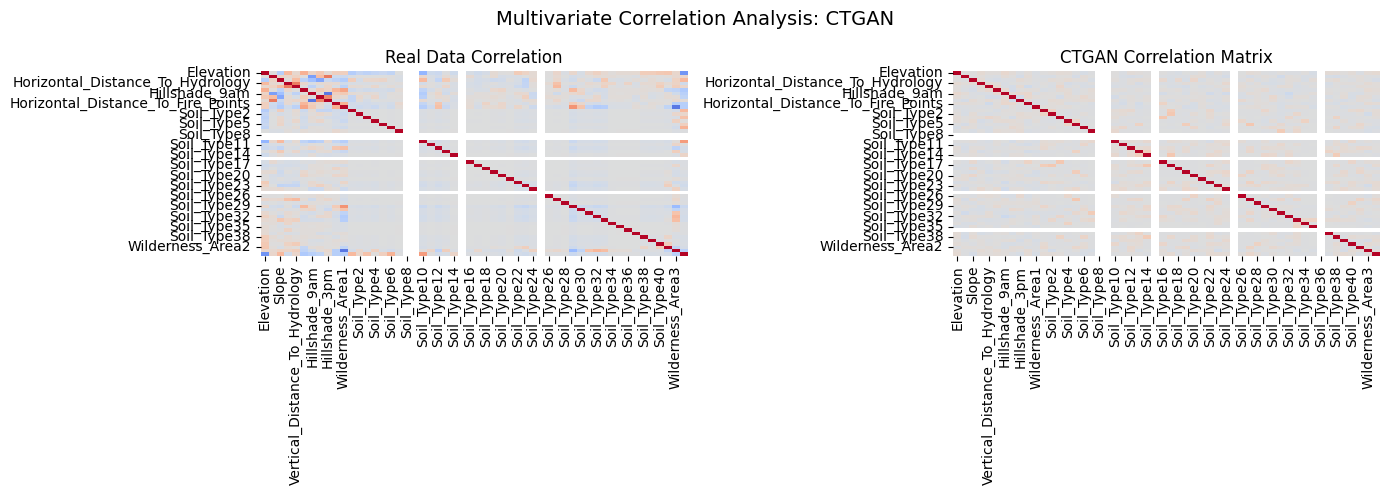

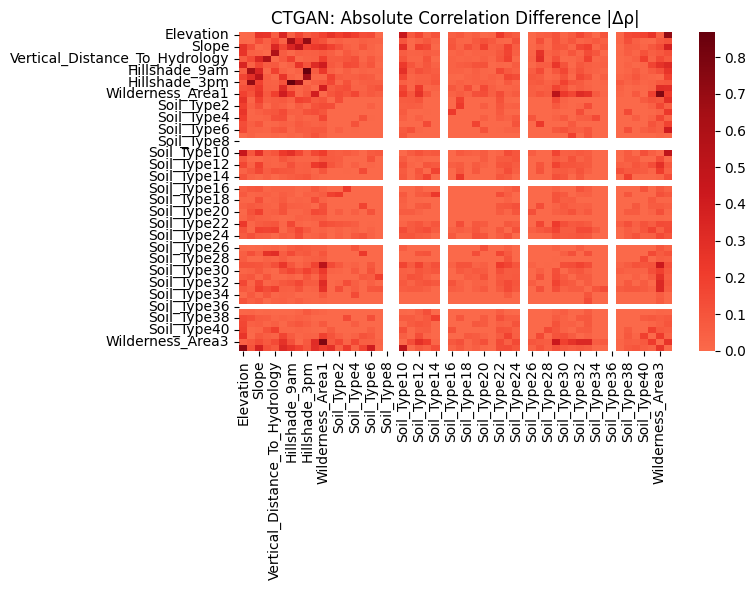

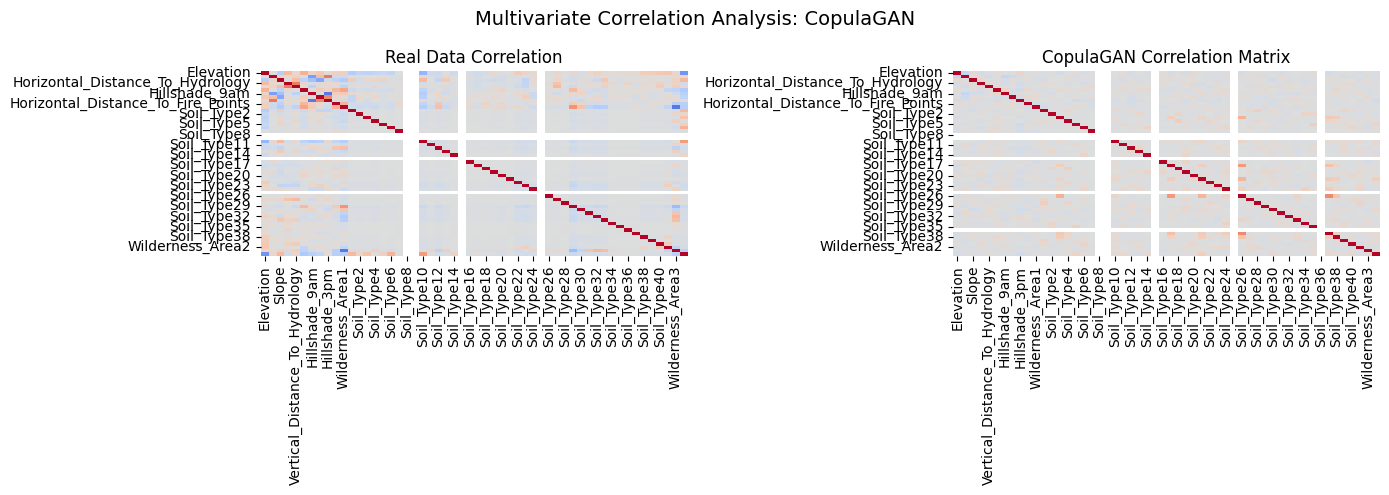

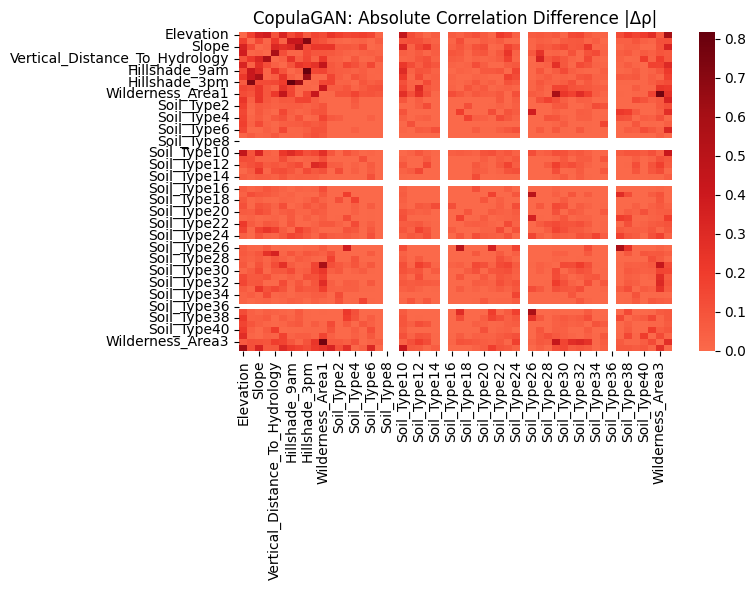

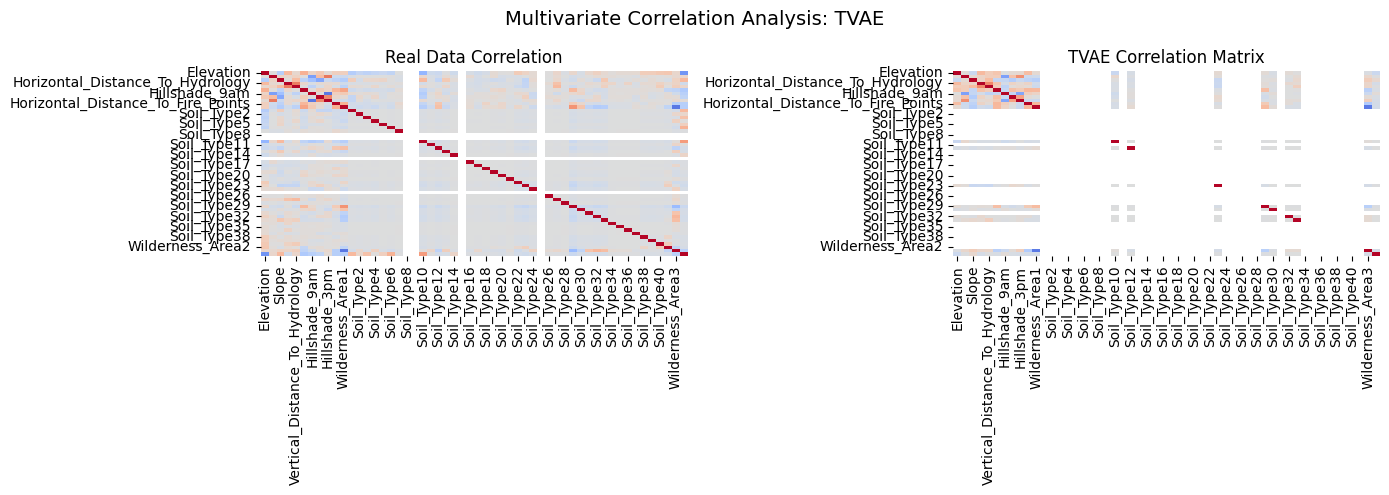

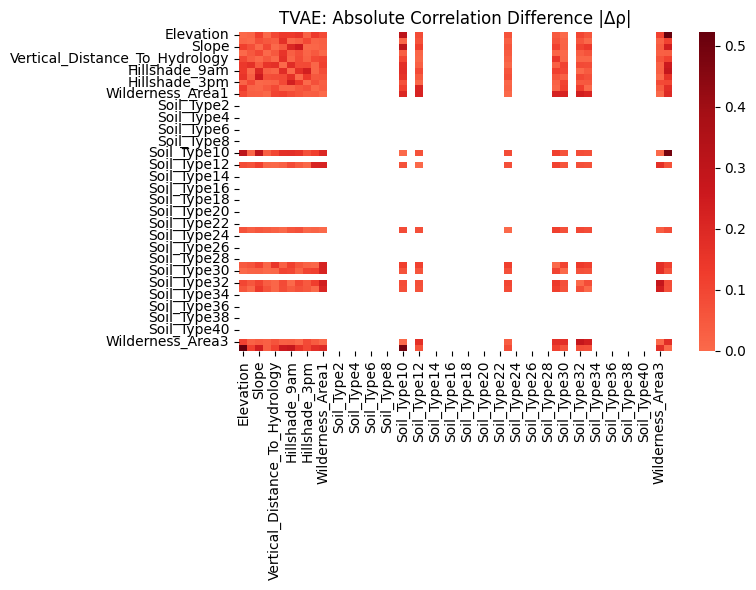

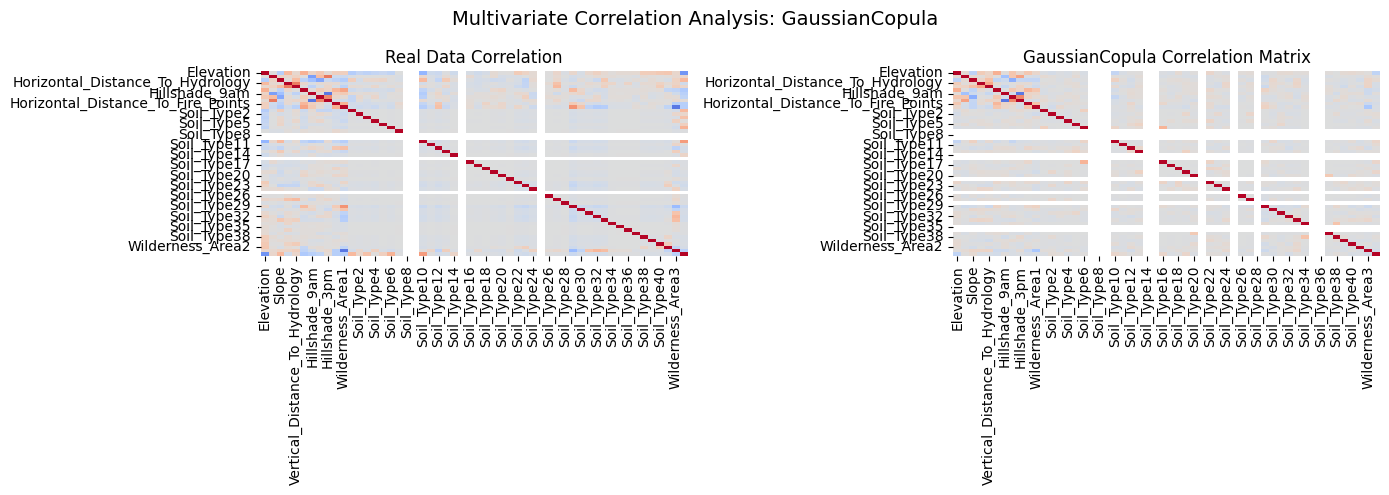

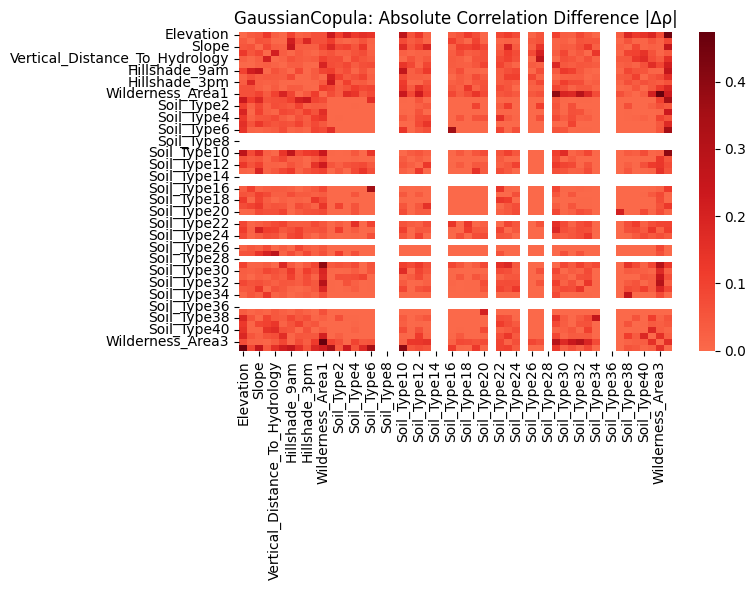

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Updated to include all four models from the analysis
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = real_sample.copy() if 'real_sample' in globals() else covertype_data.copy()
real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()

target_col = "Cover_Type"

if target_col not in real_df.columns:
    real_df = real_df.rename(columns={real_df.columns[-1]: target_col})

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

real_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce")
real_num = real_num.fillna(real_num.median(numeric_only=True))
real_corr = real_num.corr()

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"Skipping {model_name}: Model results not found.")
        continue

    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target_col not in synth_df.columns:
        synth_df = synth_df.rename(columns={synth_df.columns[-1]: target_col})

    common_num_cols = [
        c for c in num_cols
        if c in synth_df.columns
    ]

    if len(common_num_cols) < 2:
        print(f"{model_name}: Not enough numeric columns for correlation.")
        continue

    synth_num = synth_df[common_num_cols].apply(pd.to_numeric, errors="coerce")
    synth_num = synth_num.fillna(synth_num.median(numeric_only=True))
    synth_corr = synth_num.corr()

    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0], cbar=False)
    axes[0].set_title(f"Real Data Correlation")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1], cbar=False)
    axes[1].set_title(f"{model_name} Correlation Matrix")

    plt.suptitle(f"Multivariate Correlation Analysis: {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr_plot - synth_corr_plot).abs()

    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()


CTGAN - Global MMD: 0.014445


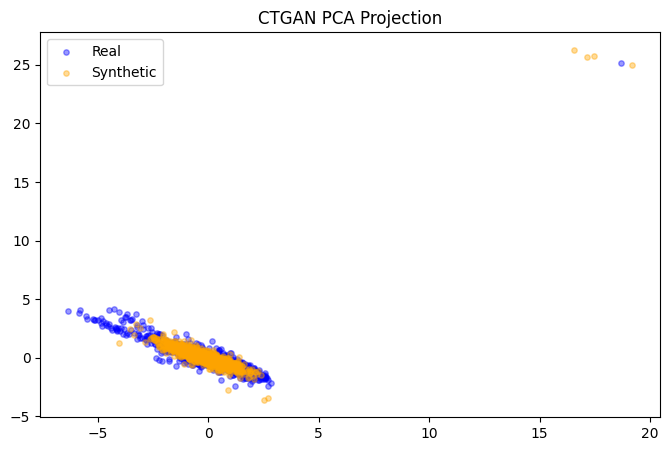

CTGAN - C2ST Accuracy: 0.9683

CopulaGAN - Global MMD: 0.026483


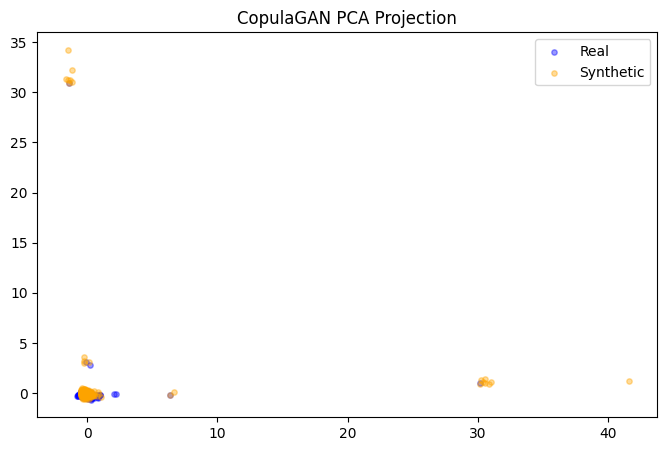

CopulaGAN - C2ST Accuracy: 0.9850

TVAE - Global MMD: 0.078140


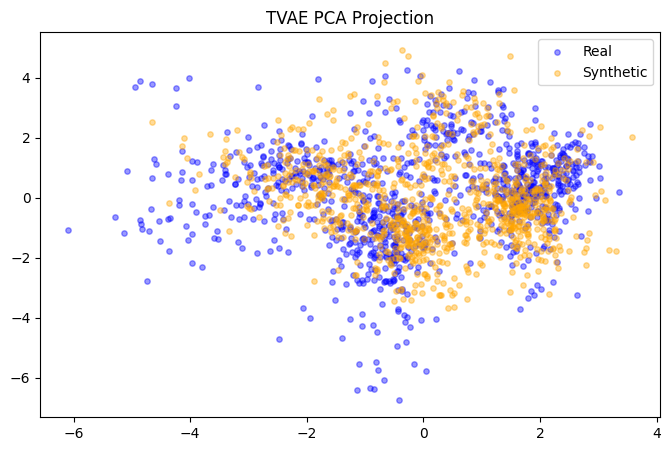

TVAE - C2ST Accuracy: 0.9150

GaussianCopula - Global MMD: 0.001040


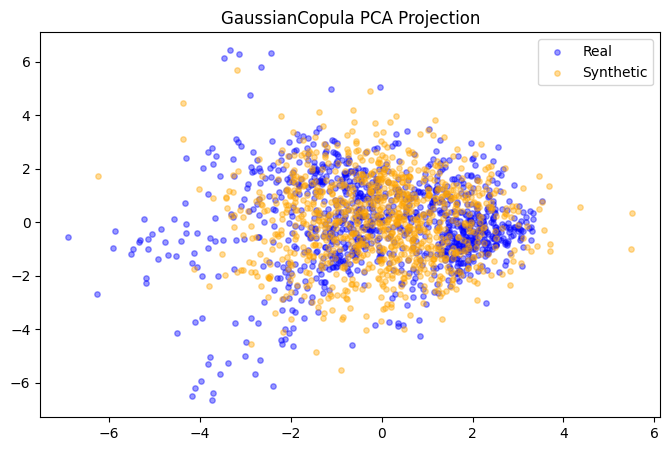

GaussianCopula - C2ST Accuracy: 0.9200


,Model,MMD,C2ST
0,CTGAN,0.014445,0.968333
1,CopulaGAN,0.026483,0.985000
2,TVAE,0.078140,0.915000
3,GaussianCopula,0.001040,0.920000


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Configuration
model_order = ['CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula']
target_col = 'Cover_Type'

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        positive_dists = dists[dists > 0]
        med = np.median(positive_dists) if len(positive_dists) > 0 else 1.0
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1)) + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1)) - 2 * Kxy.mean())

# Data Preparation
real_df = covertype_data.copy() if 'covertype_data' in globals() else real_sample.copy()
real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()

results = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        continue

    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    # Align and clean numeric columns
    X_real_df = real_df.drop(columns=[target_col], errors='ignore').select_dtypes(include=[np.number])
    X_synth_df = synth_df.drop(columns=[target_col], errors='ignore').select_dtypes(include=[np.number])
    common_cols = X_real_df.columns.intersection(X_synth_df.columns)

    X_real = X_real_df[common_cols].fillna(X_real_df[common_cols].median()).to_numpy(dtype=float)
    X_synth = X_synth_df[common_cols].fillna(X_real_df[common_cols].median()).to_numpy(dtype=float)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # MMD Calculation
    mmd_val = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f'\n{model_name} - Global MMD: {mmd_val:.6f}')

    # PCA Visualization
    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    Z = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 5))
    plt.scatter(Z[:len(X_real), 0], Z[:len(X_real), 1], color='blue', alpha=0.4, label='Real', s=15)
    plt.scatter(Z[len(X_real):, 0], Z[len(X_real):, 1], color='orange', alpha=0.4, label='Synthetic', s=15)
    plt.title(f'{model_name} PCA Projection')
    plt.legend()
    plt.show()

    # C2ST Score
    y = np.hstack([np.ones(len(X_real)), np.zeros(len(X_synth))])
    X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.3, stratify=y, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f'{model_name} - C2ST Accuracy: {acc:.4f}')

    results.append({'Model': model_name, 'MMD': mmd_val, 'C2ST': acc})

summary_df = pd.DataFrame(results)
display(summary_df)

# 4 Utility with 10 classifiers

In [53]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(),
    "SVM-RBF": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "MLP": MLPClassifier(),
}

def clean_cover_type_labels(y):
    y = pd.Series(y).copy()
    y = pd.to_numeric(y, errors="coerce")
    y = y.round().astype("Int64")
    return y

def evaluate_models(train_df, test_df, label_col="Cover_Type", models=models, test_size=0.2, seed=42, no_split=False):
    train_df = train_df.loc[:, ~train_df.columns.duplicated()].copy()
    test_df = test_df.loc[:, ~test_df.columns.duplicated()].copy()

    if label_col not in train_df.columns:
        train_df = train_df.rename(columns={train_df.columns[-1]: label_col})
    if label_col not in test_df.columns:
        test_df = test_df.rename(columns={test_df.columns[-1]: label_col})

    common_cols = train_df.columns.intersection(test_df.columns)
    train_df = train_df[common_cols].copy()
    test_df = test_df[common_cols].copy()

    num_cols = [
        c for c in common_cols
        if c != label_col
        and pd.api.types.is_numeric_dtype(train_df[c])
        and pd.api.types.is_numeric_dtype(test_df[c])
    ]

    X_train = train_df[num_cols].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[num_cols].apply(pd.to_numeric, errors="coerce")

    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    y_train = pd.to_numeric(train_df[label_col], errors="coerce").round()
    y_test = pd.to_numeric(test_df[label_col], errors="coerce").round()

    train_valid = y_train.notna()
    test_valid = y_test.notna()

    X_train = X_train.loc[train_valid]
    y_train = y_train.loc[train_valid].astype(int)

    X_test = X_test.loc[test_valid]
    y_test = y_test.loc[test_valid].astype(int)

    common_classes = sorted(set(y_train.unique()).intersection(set(y_test.unique())))

    X_train = X_train.loc[y_train.isin(common_classes)]
    y_train = y_train.loc[y_train.isin(common_classes)]

    X_test = X_test.loc[y_test.isin(common_classes)]
    y_test = y_test.loc[y_test.isin(common_classes)]

    if len(common_classes) < 2:
        raise ValueError("Need at least 2 common Cover_Type classes for classification.")

    stratify_train = y_train if y_train.value_counts().min() >= 2 else None
    stratify_test = y_test if y_test.value_counts().min() >= 2 else None

    if not no_split:
        if len(X_train) > 1:
            X_train, _, y_train, _ = train_test_split(
                X_train, y_train, test_size=test_size, random_state=seed, stratify=stratify_train
            )
        if len(X_test) > 1:
            _, X_test, _, y_test = train_test_split(
                X_test, y_test, test_size=test_size, random_state=seed, stratify=stratify_test
            )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []

    for name, clf in models.items():
        try:
            clf.fit(X_train_s, y_train)
            y_pred = clf.predict(X_test_s)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
            f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

            auc = np.nan
            if hasattr(clf, "predict_proba"):
                y_prob = clf.predict_proba(X_test_s)
                if len(clf.classes_) >= 2 and set(y_test.unique()).issubset(set(clf.classes_)):
                    try:
                        auc = roc_auc_score(
                            y_test,
                            y_prob,
                            multi_class="ovr",
                            average="macro"
                        )
                    except Exception:
                        auc = np.nan

            rows.append({
                "Model": name,
                "Accuracy": acc,
                "F1_Macro": f1_macro,
                "F1_Weighted": f1_weighted,
                "AUC_OVR_Macro": auc
            })

        except Exception as e:
            print(f"Error with {name}: {str(e)[:120]}")
            rows.append({
                "Model": name,
                "Accuracy": np.nan,
                "F1_Macro": np.nan,
                "F1_Weighted": np.nan,
                "AUC_OVR_Macro": np.nan
            })

    return pd.DataFrame(rows).sort_values(by="F1_Weighted", ascending=False)

In [54]:
import pandas as pd
import numpy as np

label_col = "Cover_Type"
# Updated to include all four models from the previous training run
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Prepare real eval data
real_eval = real_sample.copy() if 'real_sample' in globals() else covertype_data.copy()
real_eval = real_eval.loc[:, ~real_eval.columns.duplicated()].copy()

if label_col not in real_eval.columns:
    real_eval = real_eval.rename(columns={real_eval.columns[-1]: label_col})

# Ensure numeric dtypes in real_eval
for col in real_eval.columns:
    if real_eval[col].dtype == 'object':
        real_eval[col] = pd.to_numeric(real_eval[col], errors='coerce')
real_eval = real_eval.dropna()

# TRTR: Train Real, Test Real
trtr_results = evaluate_models(
    train_df=real_eval,
    test_df=real_eval,
    label="Cover_Type",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    if synth_name not in synthetic_outputs:
        print(f"Skipping {synth_name}: synthetic data not found.")
        continue

    synth_eval = synthetic_outputs[synth_name].copy()
    synth_eval = synth_eval.loc[:, ~synth_eval.columns.duplicated()].copy()

    if label_col not in synth_eval.columns:
        synth_eval = synth_eval.rename(columns={synth_eval.columns[-1]: label_col})

    # Ensure numeric dtypes in synth_eval
    for col in synth_eval.columns:
        if synth_eval[col].dtype == 'object':
            synth_eval[col] = pd.to_numeric(synth_eval[col], errors='coerce')
    synth_eval = synth_eval.dropna()

    # Align columns to match real_eval
    shared_cols = [c for c in real_eval.columns if c in synth_eval.columns]
    synth_eval = synth_eval[shared_cols]
    real_eval_aligned = real_eval[shared_cols]

    # TSTR: Train Synthetic, Test Real
    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=real_eval_aligned,
        label="Cover_Type",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    drop_metrics = {
        "AUC_OVR_Macro_Drop": ("AUC_OVR_Macro_TRTR", "AUC_OVR_Macro_TSTR"),
        "F1_Macro_Drop":      ("F1_Macro_TRTR",      "F1_Macro_TSTR"),
        "F1_Weighted_Drop":   ("F1_Weighted_TRTR",   "F1_Weighted_TSTR"),
        "Accuracy_Drop":      ("Accuracy_TRTR",      "Accuracy_TSTR"),
    }

    for drop_col, (trtr_col, tstr_col) in drop_metrics.items():
        if trtr_col in comparison.columns and tstr_col in comparison.columns:
            comparison[drop_col] = comparison[trtr_col] - comparison[tstr_col]

    comparison["Synthetic_Model"] = synth_name

    drop_priority = ["F1_Weighted_Drop", "Accuracy_Drop", "F1_Macro_Drop", "AUC_OVR_Macro_Drop"]
    sort_col = next((c for c in drop_priority if c in comparison.columns), None)

    if sort_col is not None:
        comparison = comparison.sort_values(sort_col, ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

if all_comparisons:
    combined_comparison = pd.concat(all_comparisons, ignore_index=True)

    metric_cols = [
        c for c in [
            "AUC_OVR_Macro_Drop",
            "F1_Macro_Drop",
            "F1_Weighted_Drop",
            "Accuracy_Drop"
        ]
        if c in combined_comparison.columns
    ]

    if metric_cols:
        summary = (
            combined_comparison
            .groupby("Synthetic_Model", as_index=False)[metric_cols]
            .mean()
            .sort_values(metric_cols[0])
        )
        print("Average performance drop by synthetic generator (lower is better):")
        display(summary)
    else:
        print("No drop metrics were available for summarization.")
else:
    print("No synthetic model comparisons were computed.")


TRTR (Train Real, Test Real)


,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
5,RandomForest,0.770,0.541292,0.753400,NaN
7,GradientBoost,0.755,0.556932,0.746569,NaN
6,ExtraTrees,0.740,0.539787,0.728507,NaN
0,LogReg,0.740,0.464726,0.725980,NaN
9,MLP,0.735,0.492744,0.725356,NaN
1,SVM-RBF,0.705,0.426397,0.687801,NaN
2,KNN,0.690,0.439719,0.677804,NaN
4,DecisionTree,0.670,0.434220,0.675324,NaN
8,AdaBoost,0.610,0.371315,0.563940,NaN
3,NaiveBayes,0.185,0.226705,0.174666,NaN


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
4,DecisionTree,0.380,0.139967,0.380120,NaN
2,KNN,0.380,0.138043,0.343786,NaN
9,MLP,0.360,0.131563,0.341879,NaN
8,AdaBoost,0.360,0.126820,0.312575,NaN
7,GradientBoost,0.290,0.091842,0.261606,NaN
6,ExtraTrees,0.320,0.108054,0.257814,NaN
0,LogReg,0.340,0.107222,0.249183,NaN
1,SVM-RBF,0.360,0.105929,0.241455,NaN
5,RandomForest,0.305,0.099730,0.235536,NaN
3,NaiveBayes,0.015,0.016647,0.021900,NaN


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
0,LogReg,0.665,0.304145,0.631865,NaN
5,RandomForest,0.630,0.225659,0.572551,NaN
1,SVM-RBF,0.590,0.210534,0.535467,NaN
7,GradientBoost,0.585,0.222317,0.531541,NaN
8,AdaBoost,0.550,0.201157,0.511081,NaN
9,MLP,0.500,0.190105,0.476522,NaN
6,ExtraTrees,0.520,0.184810,0.472330,NaN
4,DecisionTree,0.415,0.201456,0.426446,NaN
2,KNN,0.410,0.149808,0.373541,NaN
3,NaiveBayes,0.050,0.094191,0.038772,NaN


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_Macro_TRTR,F1_Weighted_TRTR,AUC_OVR_Macro_TRTR,Accuracy_TSTR,F1_Macro_TSTR,F1_Weighted_TSTR,AUC_OVR_Macro_TSTR,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop,Synthetic_Model
6,KNN,0.690,0.439719,0.677804,NaN,0.410,0.149808,0.373541,NaN,NaN,0.289911,0.304263,0.280,GaussianCopula
2,ExtraTrees,0.740,0.539787,0.728507,NaN,0.520,0.184810,0.472330,NaN,NaN,0.354977,0.256177,0.220,GaussianCopula
7,DecisionTree,0.670,0.434220,0.675324,NaN,0.415,0.201456,0.426446,NaN,NaN,0.232764,0.248879,0.255,GaussianCopula
4,MLP,0.735,0.492744,0.725356,NaN,0.500,0.190105,0.476522,NaN,NaN,0.302640,0.248834,0.235,GaussianCopula
1,GradientBoost,0.755,0.556932,0.746569,NaN,0.585,0.222317,0.531541,NaN,NaN,0.334615,0.215028,0.170,GaussianCopula
0,RandomForest,0.770,0.541292,0.753400,NaN,0.630,0.225659,0.572551,NaN,NaN,0.315633,0.180850,0.140,GaussianCopula
5,SVM-RBF,0.705,0.426397,0.687801,NaN,0.590,0.210534,0.535467,NaN,NaN,0.215863,0.152334,0.115,GaussianCopula
9,NaiveBayes,0.185,0.226705,0.174666,NaN,0.050,0.094191,0.038772,NaN,NaN,0.132514,0.135894,0.135,GaussianCopula
3,LogReg,0.740,0.464726,0.725980,NaN,0.665,0.304145,0.631865,NaN,NaN,0.160581,0.094115,0.075,GaussianCopula
8,AdaBoost,0.610,0.371315,0.563940,NaN,0.550,0.201157,0.511081,NaN,NaN,0.170158,0.052859,0.060,GaussianCopula


Average performance drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop
0,CTGAN,NaN,0.342802,0.381350,0.349000
1,CopulaGAN,NaN,0.313629,0.305209,0.246500
2,GaussianCopula,NaN,0.250966,0.188923,0.168500
3,TVAE,NaN,0.066309,0.086886,0.064082


TRTR (Train Real, Test Real)


,Model,Accuracy,Recall_Macro,F1_Weighted
0,LogReg,0.679,0.806216,0.696415
1,SVM-RBF,0.653,0.802043,0.671999
2,KNN,0.756,0.492721,0.747299
3,NaiveBayes,0.233,0.646356,0.222678
4,DecisionTree,0.940,0.914277,0.939992
5,RandomForest,0.949,0.912089,0.948668
6,ExtraTrees,0.947,0.917817,0.946769
7,GradientBoost,0.929,0.915573,0.928802
8,AdaBoost,0.592,0.300457,0.536633
9,MLP,0.950,0.923739,0.949853



CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Recall_Macro,F1_Weighted
0,LogReg,0.171,0.166175,0.196691
1,SVM-RBF,0.243,0.137325,0.275496
2,KNN,0.367,0.133927,0.325759
3,NaiveBayes,0.028,0.061420,0.036062
4,DecisionTree,0.272,0.117383,0.281490
5,RandomForest,0.340,0.134982,0.215692
6,ExtraTrees,0.337,0.132461,0.230060
7,GradientBoost,0.288,0.120779,0.253981
8,AdaBoost,0.361,0.132915,0.312625
9,MLP,0.354,0.124448,0.357559


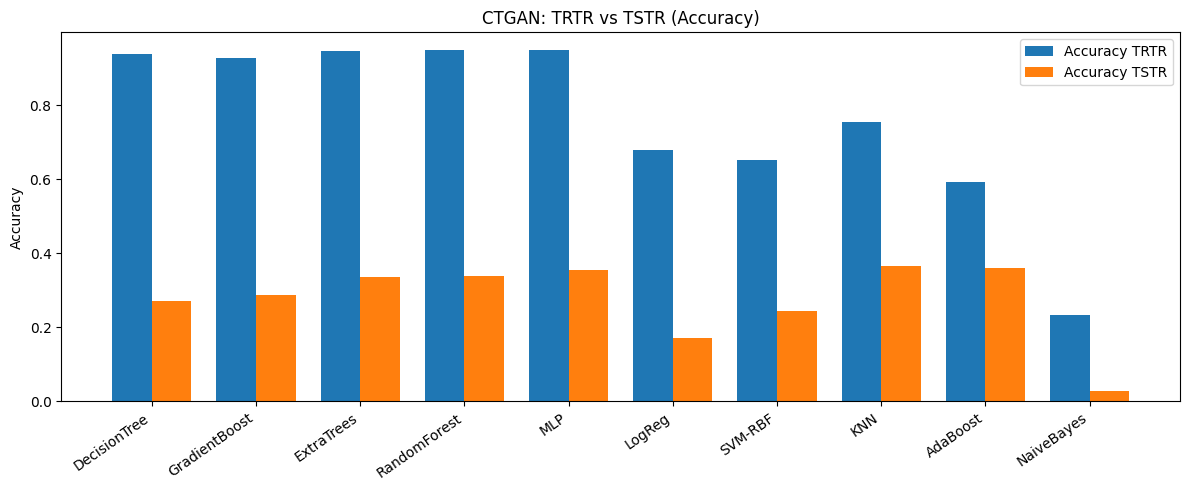

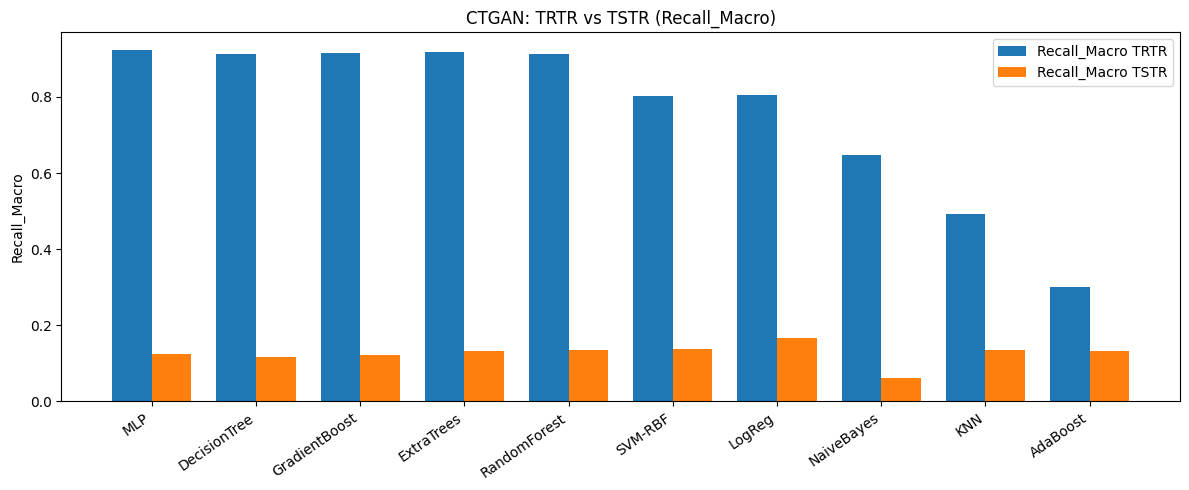

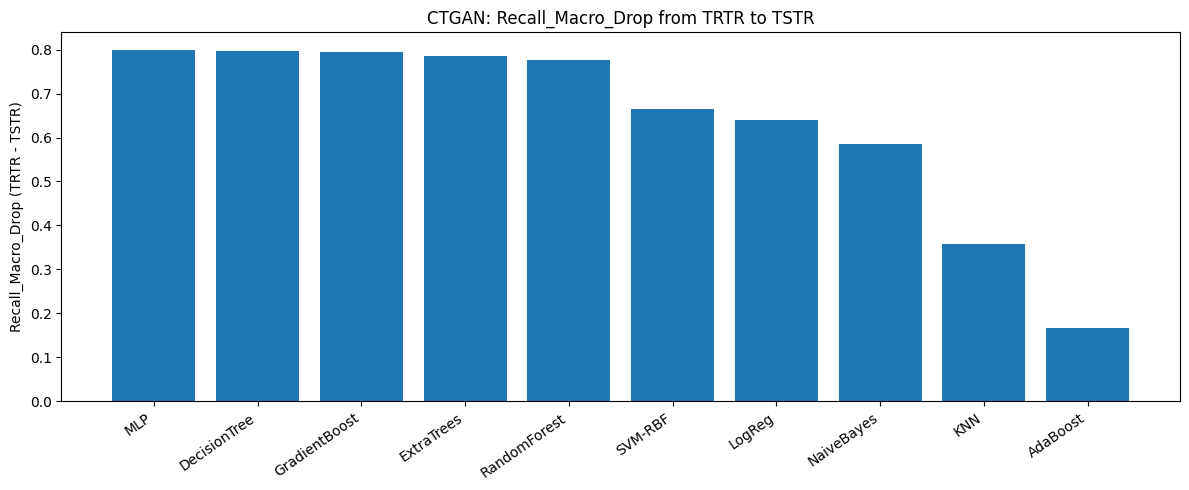


CTGAN - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Recall_Macro_TRTR,F1_Weighted_TRTR,Accuracy_TSTR,Recall_Macro_TSTR,F1_Weighted_TSTR,Accuracy_Drop,Recall_Macro_Drop,F1_Weighted_Drop,Synthetic_Model
0,LogReg,0.679,0.806216,0.696415,0.171,0.166175,0.196691,0.508,0.640040,0.499724,CTGAN
1,SVM-RBF,0.653,0.802043,0.671999,0.243,0.137325,0.275496,0.410,0.664719,0.396503,CTGAN
2,KNN,0.756,0.492721,0.747299,0.367,0.133927,0.325759,0.389,0.358794,0.421541,CTGAN
3,NaiveBayes,0.233,0.646356,0.222678,0.028,0.061420,0.036062,0.205,0.584936,0.186616,CTGAN
4,DecisionTree,0.940,0.914277,0.939992,0.272,0.117383,0.281490,0.668,0.796894,0.658502,CTGAN
5,RandomForest,0.949,0.912089,0.948668,0.340,0.134982,0.215692,0.609,0.777107,0.732976,CTGAN
6,ExtraTrees,0.947,0.917817,0.946769,0.337,0.132461,0.230060,0.610,0.785357,0.716710,CTGAN
7,GradientBoost,0.929,0.915573,0.928802,0.288,0.120779,0.253981,0.641,0.794794,0.674821,CTGAN
8,AdaBoost,0.592,0.300457,0.536633,0.361,0.132915,0.312625,0.231,0.167542,0.224008,CTGAN
9,MLP,0.950,0.923739,0.949853,0.354,0.124448,0.357559,0.596,0.799291,0.592294,CTGAN



CopulaGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Recall_Macro,F1_Weighted
0,LogReg,0.199,0.148603,0.228731
1,SVM-RBF,0.277,0.143109,0.278124
2,KNN,0.445,0.145780,0.391448
3,NaiveBayes,0.045,0.159254,0.029289
4,DecisionTree,0.318,0.147991,0.336638
5,RandomForest,0.479,0.142437,0.325440
6,ExtraTrees,0.472,0.141782,0.341147
7,GradientBoost,0.445,0.136955,0.365077
8,AdaBoost,0.498,0.155027,0.409167
9,MLP,0.386,0.146200,0.372333


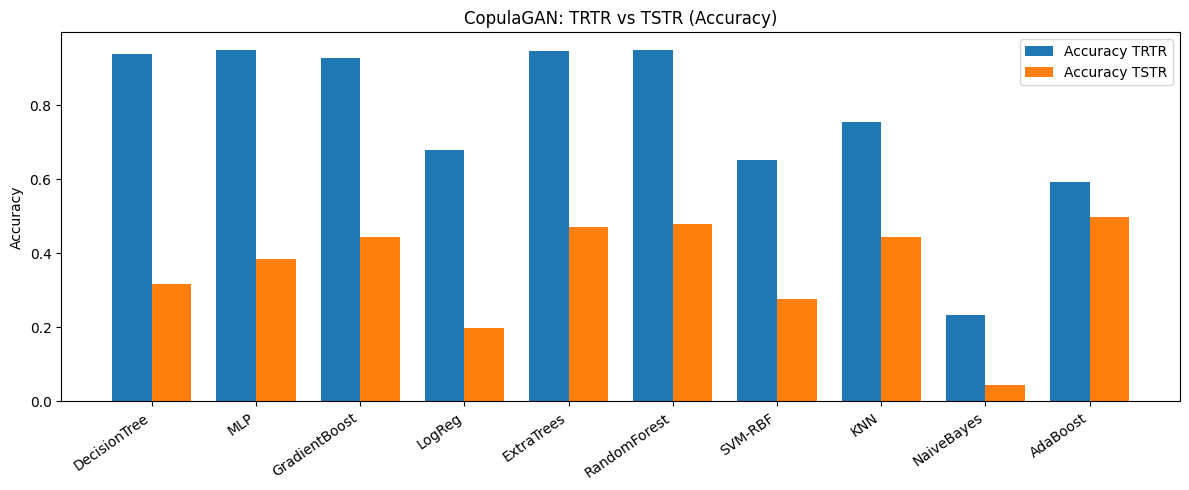

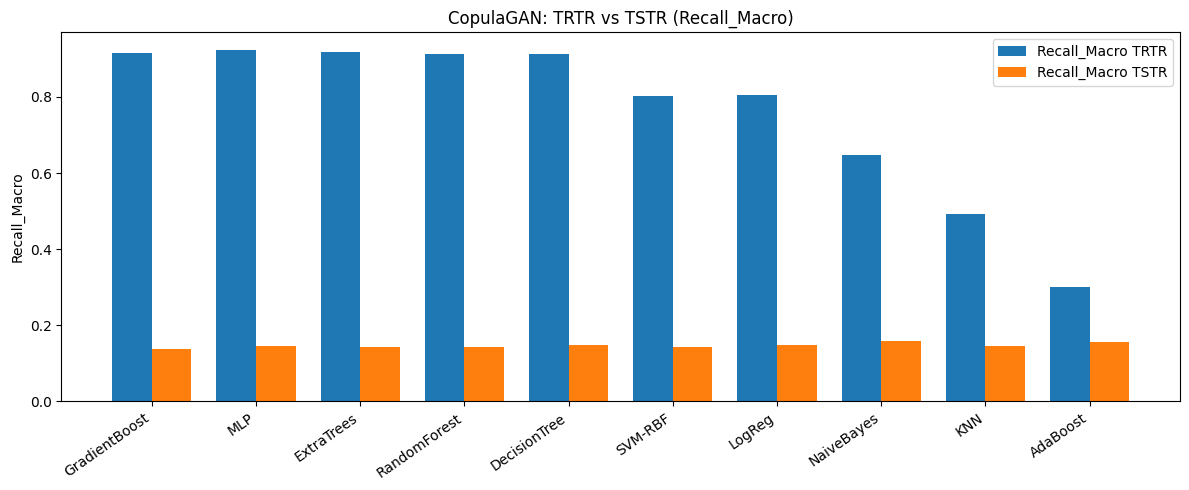

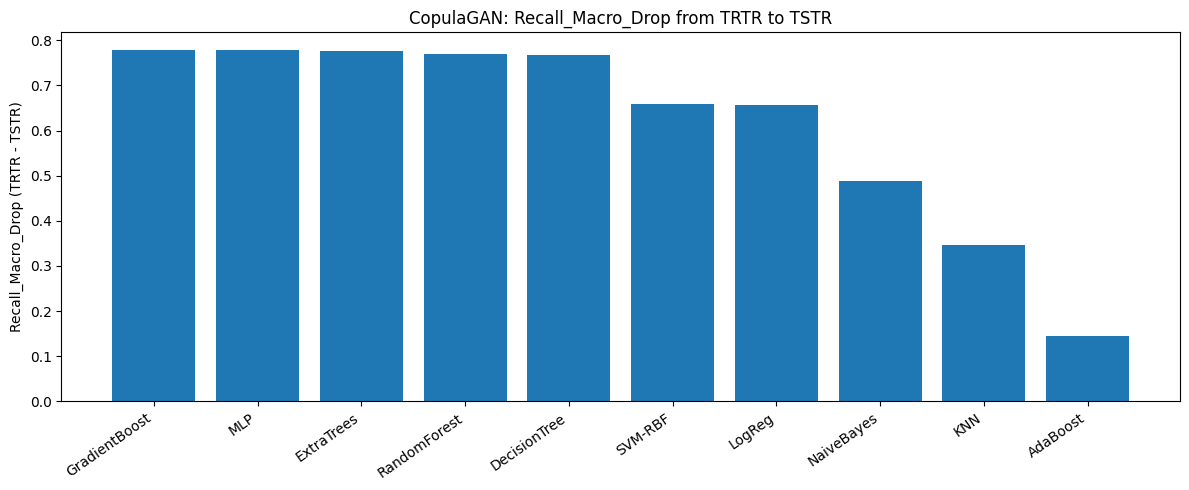


CopulaGAN - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Recall_Macro_TRTR,F1_Weighted_TRTR,Accuracy_TSTR,Recall_Macro_TSTR,F1_Weighted_TSTR,Accuracy_Drop,Recall_Macro_Drop,F1_Weighted_Drop,Synthetic_Model
0,LogReg,0.679,0.806216,0.696415,0.199,0.148603,0.228731,0.480,0.657612,0.467684,CopulaGAN
1,SVM-RBF,0.653,0.802043,0.671999,0.277,0.143109,0.278124,0.376,0.658934,0.393875,CopulaGAN
2,KNN,0.756,0.492721,0.747299,0.445,0.145780,0.391448,0.311,0.346941,0.355851,CopulaGAN
3,NaiveBayes,0.233,0.646356,0.222678,0.045,0.159254,0.029289,0.188,0.487102,0.193389,CopulaGAN
4,DecisionTree,0.940,0.914277,0.939992,0.318,0.147991,0.336638,0.622,0.766286,0.603354,CopulaGAN
5,RandomForest,0.949,0.912089,0.948668,0.479,0.142437,0.325440,0.470,0.769653,0.623228,CopulaGAN
6,ExtraTrees,0.947,0.917817,0.946769,0.472,0.141782,0.341147,0.475,0.776035,0.605623,CopulaGAN
7,GradientBoost,0.929,0.915573,0.928802,0.445,0.136955,0.365077,0.484,0.778618,0.563725,CopulaGAN
8,AdaBoost,0.592,0.300457,0.536633,0.498,0.155027,0.409167,0.094,0.145430,0.127466,CopulaGAN
9,MLP,0.950,0.923739,0.949853,0.386,0.146200,0.372333,0.564,0.777539,0.577520,CopulaGAN



TVAE - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Recall_Macro,F1_Weighted
0,LogReg,0.622,0.354624,0.615100
1,SVM-RBF,0.583,0.260054,0.555269
2,KNN,0.560,0.258804,0.522023
3,NaiveBayes,0.459,0.298345,0.405303
4,DecisionTree,0.580,0.215125,0.530831
5,RandomForest,0.592,0.189801,0.518449
6,ExtraTrees,0.583,0.246870,0.526338
7,GradientBoost,0.634,0.311640,0.605480
8,AdaBoost,0.490,0.169825,0.389151
9,MLP,0.597,0.279015,0.569651


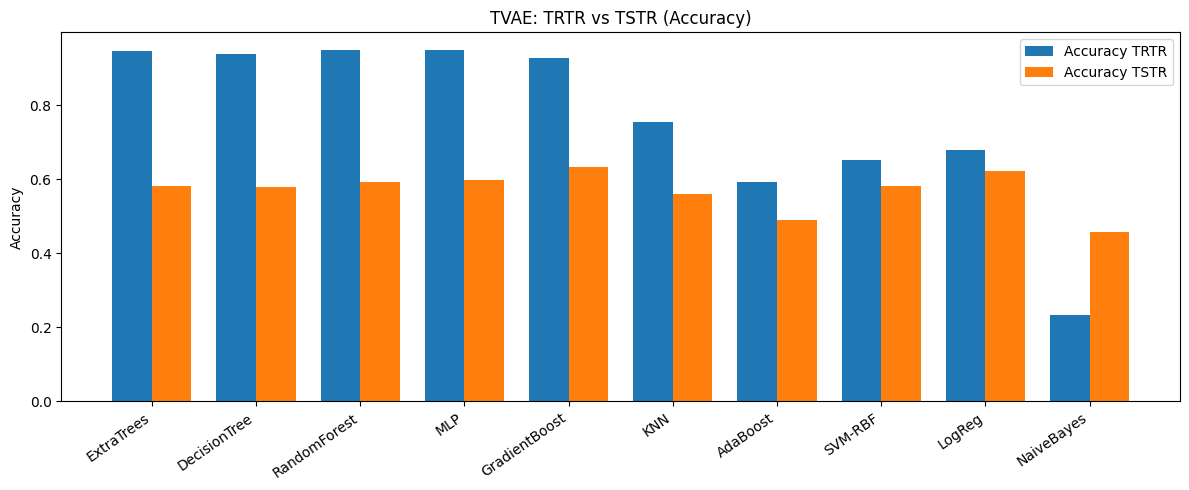

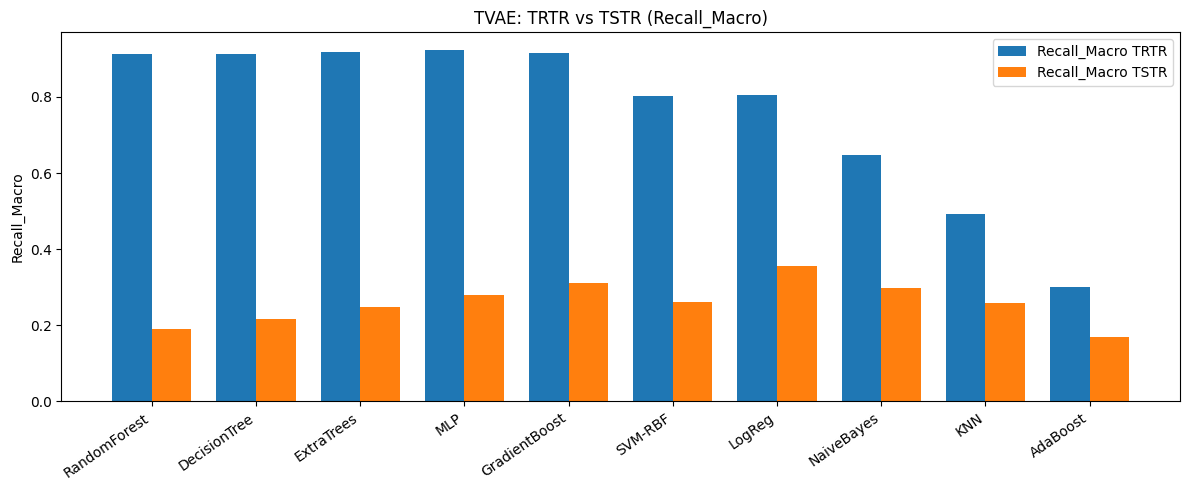

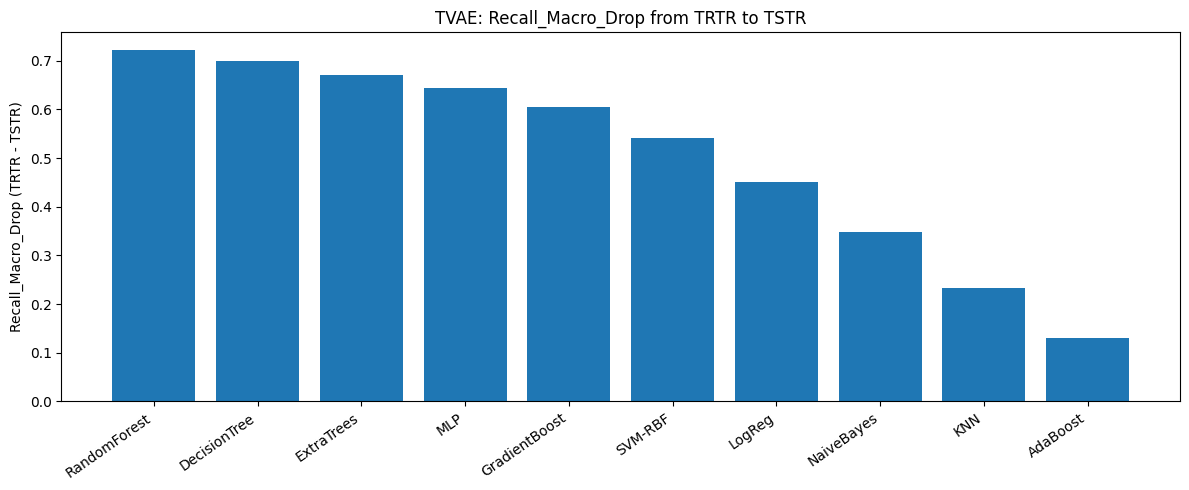


TVAE - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Recall_Macro_TRTR,F1_Weighted_TRTR,Accuracy_TSTR,Recall_Macro_TSTR,F1_Weighted_TSTR,Accuracy_Drop,Recall_Macro_Drop,F1_Weighted_Drop,Synthetic_Model
0,LogReg,0.679,0.806216,0.696415,0.622,0.354624,0.615100,0.057,0.451591,0.081315,TVAE
1,SVM-RBF,0.653,0.802043,0.671999,0.583,0.260054,0.555269,0.070,0.541989,0.116730,TVAE
2,KNN,0.756,0.492721,0.747299,0.560,0.258804,0.522023,0.196,0.233917,0.225276,TVAE
3,NaiveBayes,0.233,0.646356,0.222678,0.459,0.298345,0.405303,-0.226,0.348011,-0.182625,TVAE
4,DecisionTree,0.940,0.914277,0.939992,0.580,0.215125,0.530831,0.360,0.699152,0.409161,TVAE
5,RandomForest,0.949,0.912089,0.948668,0.592,0.189801,0.518449,0.357,0.722288,0.430218,TVAE
6,ExtraTrees,0.947,0.917817,0.946769,0.583,0.246870,0.526338,0.364,0.670948,0.420432,TVAE
7,GradientBoost,0.929,0.915573,0.928802,0.634,0.311640,0.605480,0.295,0.603932,0.323322,TVAE
8,AdaBoost,0.592,0.300457,0.536633,0.490,0.169825,0.389151,0.102,0.130632,0.147482,TVAE
9,MLP,0.950,0.923739,0.949853,0.597,0.279015,0.569651,0.353,0.644724,0.380202,TVAE



GaussianCopula - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Recall_Macro,F1_Weighted
0,LogReg,0.335,0.188851,0.364166
1,SVM-RBF,0.399,0.229447,0.405516
2,KNN,0.384,0.134272,0.352820
3,NaiveBayes,0.042,0.132947,0.030645
4,DecisionTree,0.413,0.179012,0.420533
5,RandomForest,0.569,0.185830,0.508075
6,ExtraTrees,0.540,0.178779,0.486136
7,GradientBoost,0.566,0.207307,0.526857
8,AdaBoost,0.529,0.178901,0.485880
9,MLP,0.443,0.194496,0.432252


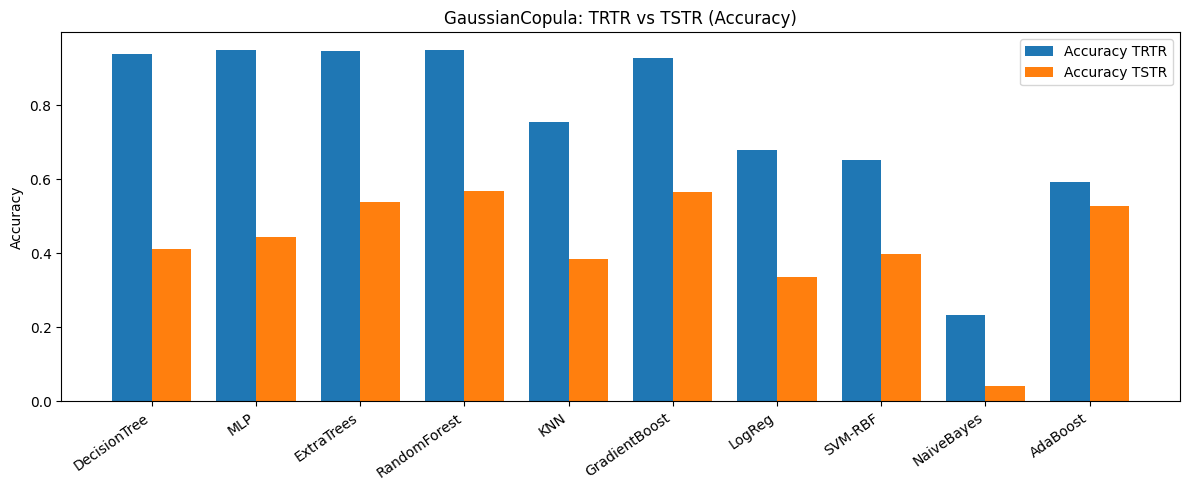

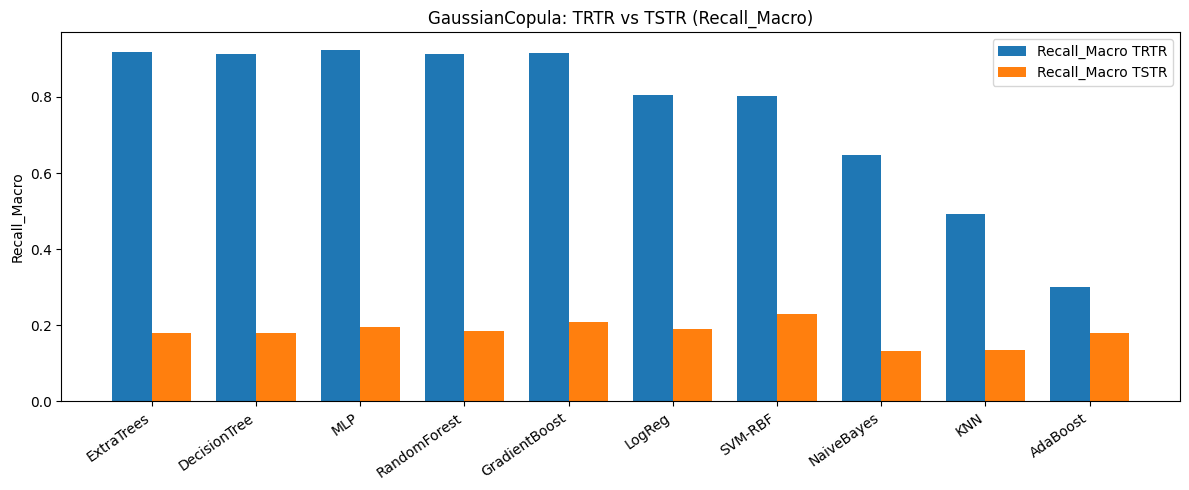

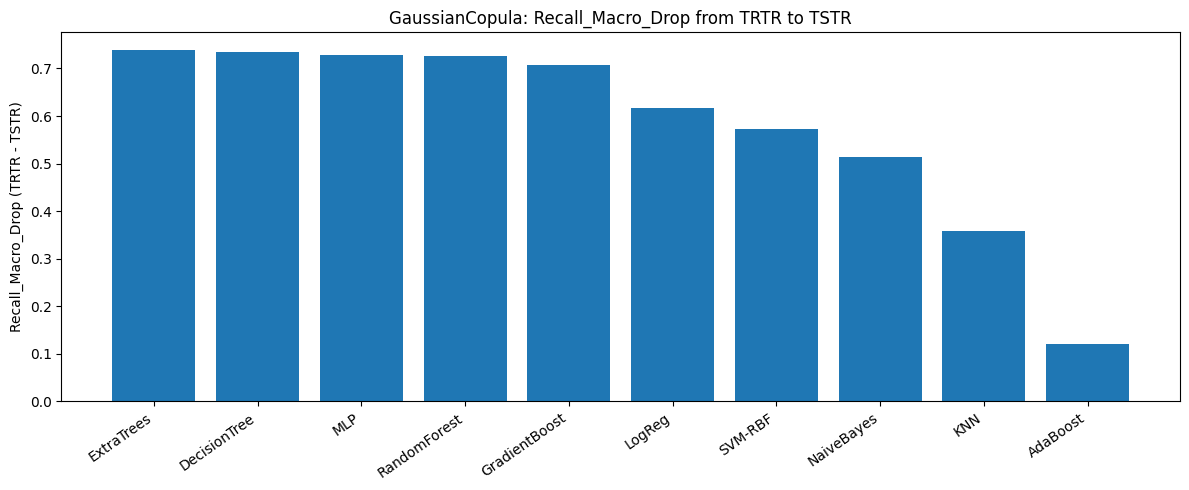


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Recall_Macro_TRTR,F1_Weighted_TRTR,Accuracy_TSTR,Recall_Macro_TSTR,F1_Weighted_TSTR,Accuracy_Drop,Recall_Macro_Drop,F1_Weighted_Drop,Synthetic_Model
0,LogReg,0.679,0.806216,0.696415,0.335,0.188851,0.364166,0.344,0.617365,0.332249,GaussianCopula
1,SVM-RBF,0.653,0.802043,0.671999,0.399,0.229447,0.405516,0.254,0.572596,0.266483,GaussianCopula
2,KNN,0.756,0.492721,0.747299,0.384,0.134272,0.352820,0.372,0.358448,0.394479,GaussianCopula
3,NaiveBayes,0.233,0.646356,0.222678,0.042,0.132947,0.030645,0.191,0.513409,0.192033,GaussianCopula
4,DecisionTree,0.940,0.914277,0.939992,0.413,0.179012,0.420533,0.527,0.735265,0.519459,GaussianCopula
5,RandomForest,0.949,0.912089,0.948668,0.569,0.185830,0.508075,0.380,0.726259,0.440593,GaussianCopula
6,ExtraTrees,0.947,0.917817,0.946769,0.540,0.178779,0.486136,0.407,0.739039,0.460634,GaussianCopula
7,GradientBoost,0.929,0.915573,0.928802,0.566,0.207307,0.526857,0.363,0.708266,0.401945,GaussianCopula
8,AdaBoost,0.592,0.300457,0.536633,0.529,0.178901,0.485880,0.063,0.121556,0.050753,GaussianCopula
9,MLP,0.950,0.923739,0.949853,0.443,0.194496,0.432252,0.507,0.729243,0.517600,GaussianCopula



Average performance drop by synthetic generator (lower is better):


,Synthetic_Model,Accuracy_Drop,Recall_Macro_Drop,F1_Weighted_Drop
3,TVAE,0.1928,0.504718,0.235151
2,GaussianCopula,0.3408,0.582145,0.357623
1,CopulaGAN,0.4064,0.616415,0.451172
0,CTGAN,0.4867,0.636947,0.510369


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        print(f"Skipping {metric}: not found.")
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    df = df.dropna(subset=[f"{metric}_TRTR", f"{metric}_TSTR"])

    if df.empty:
        print(f"Skipping {metric}: no valid values.")
        return

    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_drop(comparison_df, synth_name, drop_col):
    if drop_col not in comparison_df.columns:
        print(f"Skipping {drop_col}: not found.")
        return

    df = comparison_df.dropna(subset=[drop_col]).sort_values(drop_col, ascending=False)

    if df.empty:
        print(f"Skipping {drop_col}: no valid values.")
        return

    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[drop_col])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(f"{drop_col} (TRTR - TSTR)")
    plt.title(f"{synth_name}: {drop_col} from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "Cover_Type"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Ensure real_sample exists
if 'real_sample' not in globals():
    real_sample = covertype_data.copy()

data_eval = real_sample.copy()
data_eval = data_eval.loc[:, ~data_eval.columns.duplicated()].copy()

if label_col not in data_eval.columns:
    data_eval = data_eval.rename(columns={data_eval.columns[-1]: label_col})

trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label="Cover_Type",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comp = []

for synth_name in model_order:
    if synth_name not in synthetic_outputs:
        print(f"Skipping {synth_name}: Data not found.")
        continue

    synth_df = synthetic_outputs[synth_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    tstr_results = evaluate_models(
        train_df=synth_df,
        test_df=data_eval,
        label="Cover_Type",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    # Only use metrics known to be returned by evaluate_models
    metric_cols = ["Accuracy", "Recall_Macro", "F1_Weighted"]

    for metric in metric_cols:
        trtr_col = f"{metric}_TRTR"
        tstr_col = f"{metric}_TSTR"

        if trtr_col in comparison.columns and tstr_col in comparison.columns:
            comparison[f"{metric}_Drop"] = comparison[trtr_col] - comparison[tstr_col]

    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    for metric in ["Accuracy", "Recall_Macro"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_metric_drop(comparison, synth_name, "Recall_Macro_Drop")

    print(f"\n{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

if all_comp:
    combined_comparison = pd.concat(all_comp, ignore_index=True)
    drop_cols = [c for c in ["Accuracy_Drop", "Recall_Macro_Drop", "F1_Weighted_Drop"] if c in combined_comparison.columns]

    if "Recall_Macro_Drop" in combined_comparison.columns:
        summary = (
            combined_comparison
            .groupby("Synthetic_Model", as_index=False)[drop_cols]
            .mean()
            .sort_values("Recall_Macro_Drop")
        )

        print("\nAverage performance drop by synthetic generator (lower is better):")
        display(summary)
    else:
        print("No drop metrics available for summary.")
else:
    print("No comparisons computed.")


### 9. Diversity and Privacy Audit
In this final phase, we analyze:
1. **Gower Distance**: Measures how 'unique' synthetic samples are. Higher similarity to real data can sometimes indicate lower diversity or potential memorization.
2. **Membership Inference Attack (MIA)**: A privacy audit that determines if a classifier can distinguish between real training samples and synthetic samples. An AUC close to 0.5 indicates strong privacy.

In [65]:
import gower
import numpy as np
import pandas as pd

# Sample for Gower distance due to O(N^2) complexity
G_SAMPLE = 500
real_gower = covertype_data.sample(min(len(covertype_data), G_SAMPLE), random_state=42)

gower_results = []
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for name in model_order:
    if name in synthetic_outputs:
        synth_sample = synthetic_outputs[name].sample(min(len(synthetic_outputs[name]), G_SAMPLE), random_state=42)

        # Standardize columns
        common_cols = real_gower.columns.intersection(synth_sample.columns)
        # Fix: Cast to float to avoid UFuncTypeError during normalization in gower library
        Xr = real_gower[common_cols].copy().astype(float)
        Xs = synth_sample[common_cols].copy().astype(float)

        # 1 - Gower Distance = Similarity
        g_matrix = 1 - gower.gower_matrix(Xr, Xs)
        avg_sim = np.mean(g_matrix)

        gower_results.append({"Model": name, "Avg_Gower_Similarity": avg_sim})

gower_df = pd.DataFrame(gower_results).sort_values("Avg_Gower_Similarity")
print("Diversity Audit: Average Gower Similarity (Lower is generally better for diversity)")
display(gower_df)

Diversity Audit: Average Gower Similarity (Lower is generally better for diversity)


,Model,Avg_Gower_Similarity
1,CopulaGAN,0.898927
0,CTGAN,0.899634
3,GaussianCopula,0.903380
2,TVAE,0.921250


In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def audit_mia(real_df, synth_df, target):
    # Prepare features and alignment
    r_feat = real_df.drop(columns=[target], errors='ignore')
    s_feat = synth_df.drop(columns=[target], errors='ignore')
    cols = r_feat.columns.intersection(s_feat.columns)

    # Combine: Real = 1, Synthetic = 0
    X = pd.concat([r_feat[cols], s_feat[cols]], axis=0).fillna(0)
    y = np.array([1] * len(r_feat) + [0] * len(s_feat))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    # Train discriminator
    discriminator = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    discriminator.fit(X_train, y_train)

    probs = discriminator.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, probs)

mia_list = []
for name in model_order:
    if name in synthetic_outputs:
        auc = audit_mia(covertype_data, synthetic_outputs[name], "Cover_Type")
        mia_list.append({"Model": name, "MIA_AUC": auc})

mia_df = pd.DataFrame(mia_list).sort_values("MIA_AUC")
print("\nPrivacy Audit: MIA AUC (AUC of 0.5 is ideal for privacy)")
display(mia_df)


Privacy Audit: MIA AUC (AUC of 0.5 is ideal for privacy)


,Model,MIA_AUC
2,TVAE,0.947922
3,GaussianCopula,0.956956
0,CTGAN,0.987111
1,CopulaGAN,0.998644


### 9. Diversity and Privacy Audit
In this final section, we evaluate:
1. **Gower Distance**: To ensure the synthetic data is diverse and not just a memorized subset of the real data.
2. **Membership Inference Attack (MIA)**: To determine if a classifier can distinguish between training data and synthetic data, which serves as a proxy for privacy leakage.

In [64]:
import gower
import numpy as np
import pandas as pd

def prepare_for_gower(real_df, synth_df):
    # Align columns and handle missing values
    common_cols = real_df.columns.intersection(synth_df.columns)
    # Cast to float to avoid UFuncTypeError in the gower library
    Xr = real_df[common_cols].copy().astype(float)
    Xs = synth_df[common_cols].copy().astype(float)
    return Xr, Xs, common_cols

gower_results = []
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# We use a smaller sample for Gower distance as it is computationally expensive O(N^2)
SAMPLE_GOWER = 500
if 'covertype_data' in globals():
    X_real_gower = covertype_data.sample(min(len(covertype_data), SAMPLE_GOWER), random_state=42)

    for name in model_order:
        if name in synthetic_outputs:
            X_synth = synthetic_outputs[name].sample(min(len(synthetic_outputs[name]), SAMPLE_GOWER), random_state=42)
            Xr, Xs, _ = prepare_for_gower(X_real_gower, X_synth)

            # Compute cross-similarity matrix
            # 1 - distance = similarity
            g_matrix = 1 - gower.gower_matrix(Xr, Xs)
            avg_sim = np.mean(g_matrix)

            gower_results.append({"Model": name, "Avg_Gower_Similarity": avg_sim})

    gower_summary = pd.DataFrame(gower_results).sort_values("Avg_Gower_Similarity")
    print("Diversity Audit: Average Gower Similarity (Lower indicates higher diversity/lower memorization)")
    display(gower_summary)
else:
    print("Error: covertype_data not found in kernel context.")

Diversity Audit: Average Gower Similarity (Lower indicates higher diversity/lower memorization)


,Model,Avg_Gower_Similarity
1,CopulaGAN,0.898927
0,CTGAN,0.899634
3,GaussianCopula,0.903380
2,TVAE,0.921250


In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def run_mia_audit(real_df, synth_df, target_col):
    # Combine real and synthetic data with labels (1 for real, 0 for synthetic)
    real_features = real_df.drop(columns=[target_col], errors='ignore')
    synth_features = synth_df.drop(columns=[target_col], errors='ignore')

    # Align columns
    cols = real_features.columns.intersection(synth_features.columns)
    X = pd.concat([real_features[cols], synth_features[cols]], axis=0)
    y = np.array([1] * len(real_features) + [0] * len(synth_features))

    # Train a discriminator to see if it can distinguish real from synthetic
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    clf.fit(X_train.fillna(0), y_train)

    probs = clf.predict_proba(X_test.fillna(0))[:, 1]
    auc = roc_auc_score(y_test, probs)
    return auc

mia_results = []
for name in model_order:
    if name in synthetic_outputs:
        auc_score = run_mia_audit(covertype_data, synthetic_outputs[name], "Cover_Type")
        mia_results.append({"Model": name, "MIA_AUC": auc_score})

mia_summary = pd.DataFrame(mia_results).sort_values("MIA_AUC")
print("\nPrivacy Audit: Membership Inference AUC (Lower is better, ~0.5 means indistinguishable)")
display(mia_summary)


Privacy Audit: Membership Inference AUC (Lower is better, ~0.5 means indistinguishable)


,Model,MIA_AUC
2,TVAE,0.947922
3,GaussianCopula,0.956956
0,CTGAN,0.987111
1,CopulaGAN,0.998644


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    # Adjusted metrics to match the available results (Accuracy, Recall_Macro, F1_Weighted)
    metrics = ["Accuracy", "Recall_Macro", "F1_Weighted"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

# Configuration for the four main SDV models
label_col = "Cover_Type"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Clean and prepare real data
data_eval = real_sample.copy() if 'real_sample' in globals() else covertype_data.copy()
data_eval[label_col] = clean_cover_type_labels(data_eval[label_col])

# TRTR baseline
print("Computing TRTR Baseline...")
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label="Cover_Type",
    models=models
)

for gen in generators:
    if gen not in synthetic_outputs:
        print(f"Skipping {gen}: Data not found.")
        continue

    print(f"\nEvaluating {gen}...")
    synth_eval = synthetic_outputs[gen].copy()
    if label_col in synth_eval.columns:
        synth_eval[label_col] = clean_cover_type_labels(synth_eval[label_col])

    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=data_eval,
        label="Cover_Type",
        models=models
    )

    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests

Average Statistical Error by Model (Lower is Better)


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,40.198757,17.072214,19.948572
1,CopulaGAN,72.636275,26.269562,27.780323
2,TVAE,76.959918,100.000000,74.108926
3,GaussianCopula,26.610770,12.047101,20.321263


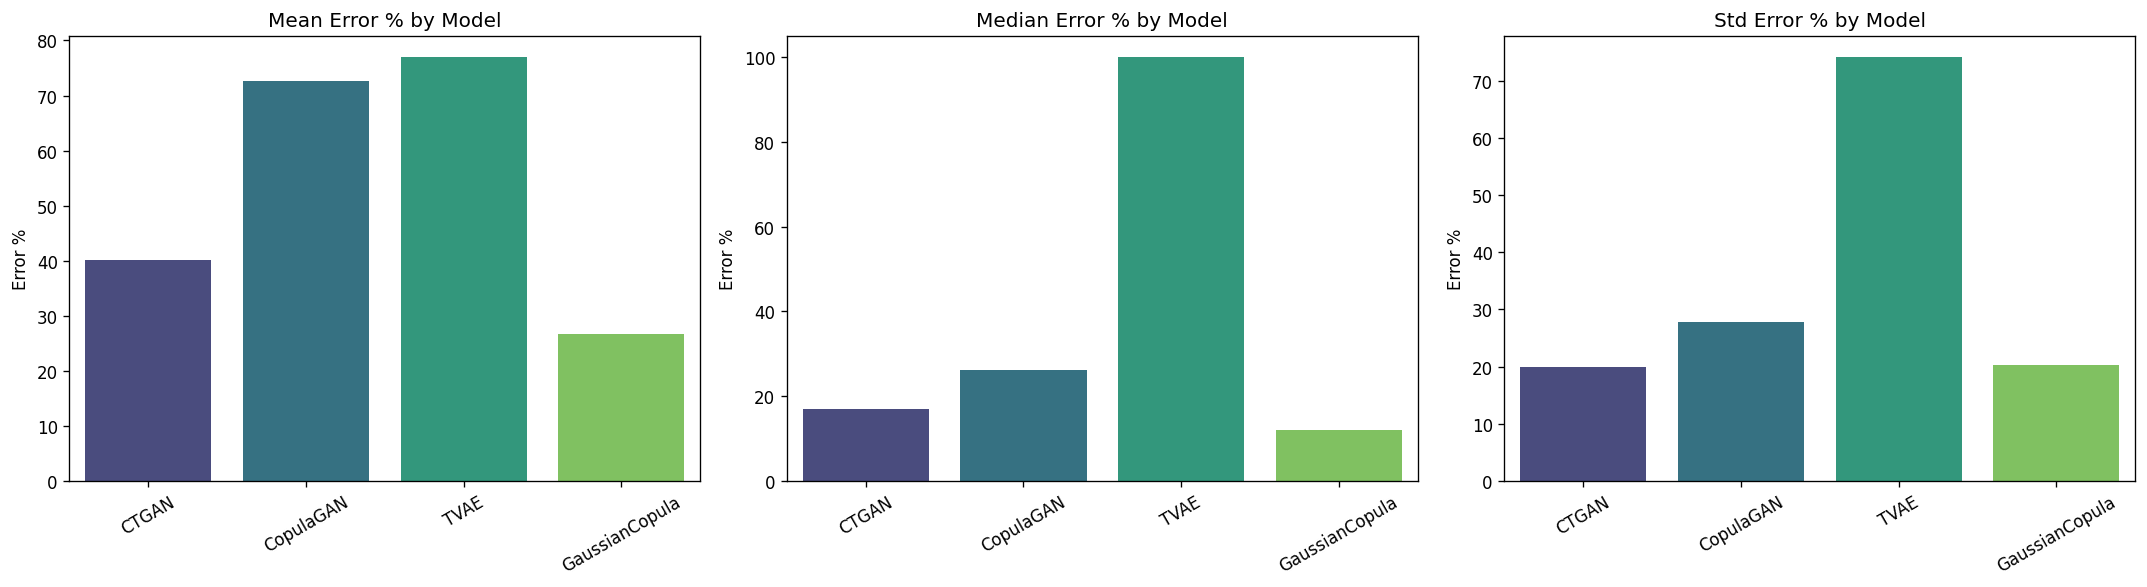

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to include all four main models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Cover_Type"
real_df = covertype_data.copy() if 'covertype_data' in globals() else real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    if model_name not in synthetic_outputs:
        continue

    synth_df = synthetic_outputs[model_name].copy()

    # Align columns and handle NaN using real data medians
    common_num = [c for c in num_cols if c in synth_df.columns]
    real_medians = real_df[common_num].median()

    synth_df_aligned = synth_df[common_num].fillna(real_medians)
    real_df_aligned = real_df[common_num].fillna(real_medians)

    real_means = real_df_aligned.mean()
    synth_means = synth_df_aligned.mean()

    real_stds = real_df_aligned.std(ddof=1)
    synth_stds = synth_df_aligned.std(ddof=1)

    # Calculate percentage errors
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": common_num,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
# Maintain consistent ordering
summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=model_order, ordered=True)
summary_df = summary_df.sort_values("Model")

print("Average Statistical Error by Model (Lower is Better)")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)
metrics = ["Mean Error %", "Median Error %", "Std Error %"]

for i, metric in enumerate(metrics):
    sns.barplot(data=summary_df, x="Model", y=metric, ax=axes[i], palette="viridis", hue="Model", legend=False)
    axes[i].set_title(f"{metric} by Model")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Error %")

plt.tight_layout()
plt.show()

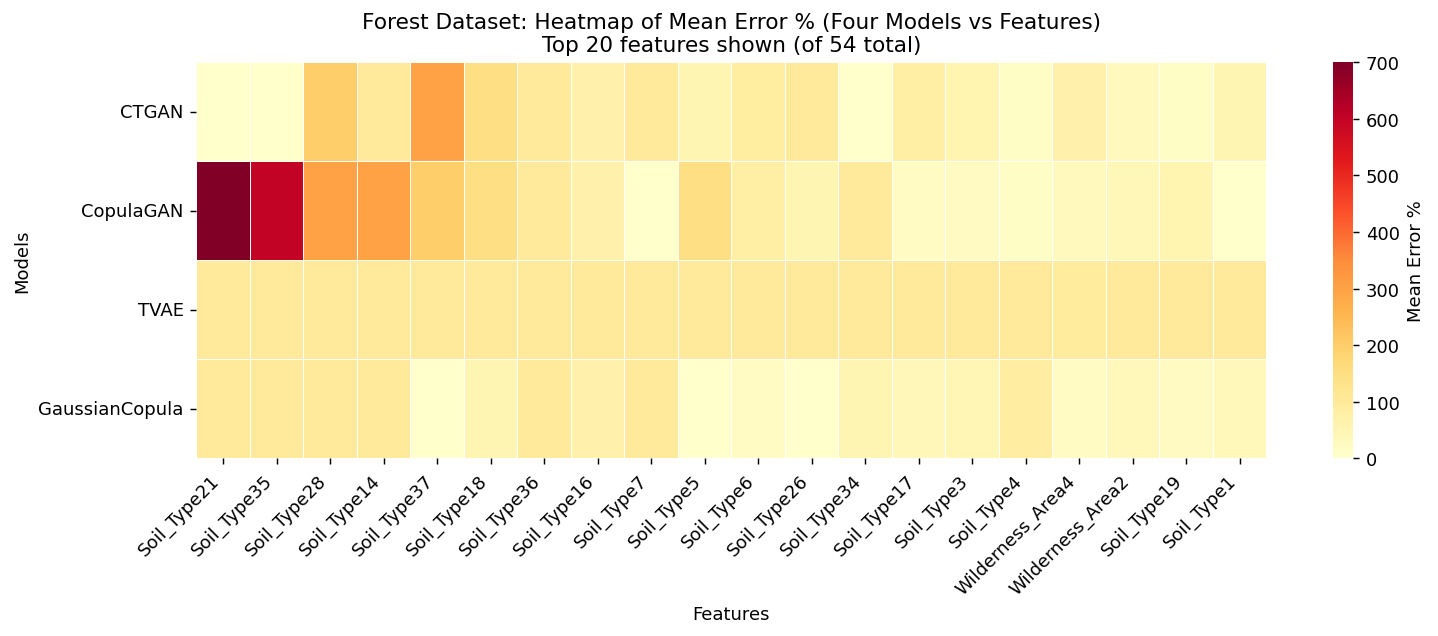

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to include all four primary models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Create heatmap from feature_error_by_model (calculated in previous cells)
heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

# Display top 20 features by average error for better readability
max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(12, 0.6 * len(display_labels)), 5), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Forest Dataset: Heatmap of Mean Error % (Four Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

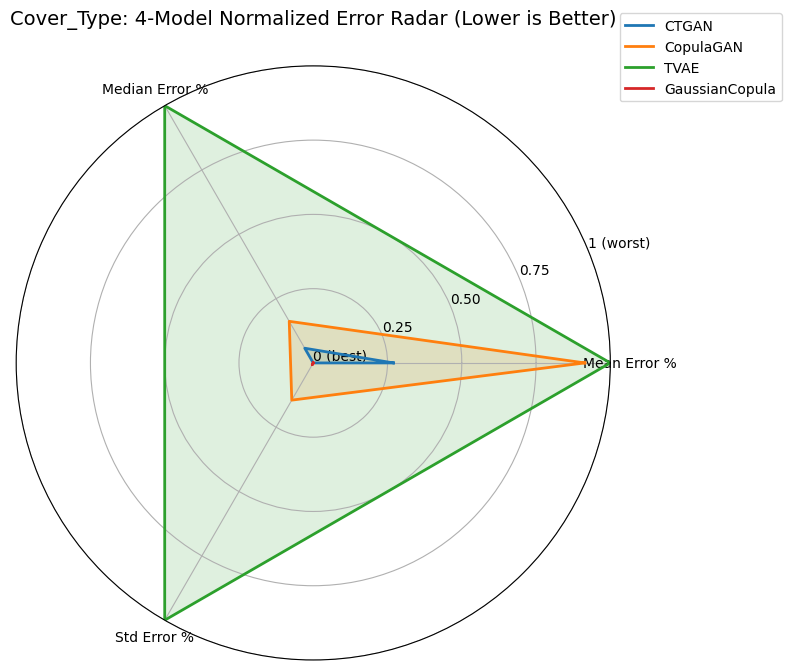

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.269875,0.057134,0.000000
1,CopulaGAN,0.914127,0.161705,0.144603
2,TVAE,1.000000,1.000000,1.000000
3,GaussianCopula,0.000000,0.000000,0.006881


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we use the latest summary_df containing all four models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
metrics = ["Mean Error %", "Median Error %", "Std Error %"]

# Filter summary_df to ensure it matches our four models
radar_df = summary_df[summary_df['Model'].isin(model_order)][["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each model
for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.15)

# Fix labels and axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Cover_Type: 4-Model Normalized Error Radar (Lower is Better)", pad=30, fontsize=14)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,GaussianCopula,6.648148,2.5,42
1,CopulaGAN,7.037037,3.0,66
2,CTGAN,8.037037,3.0,48
3,TVAE,23.759259,11.5,124


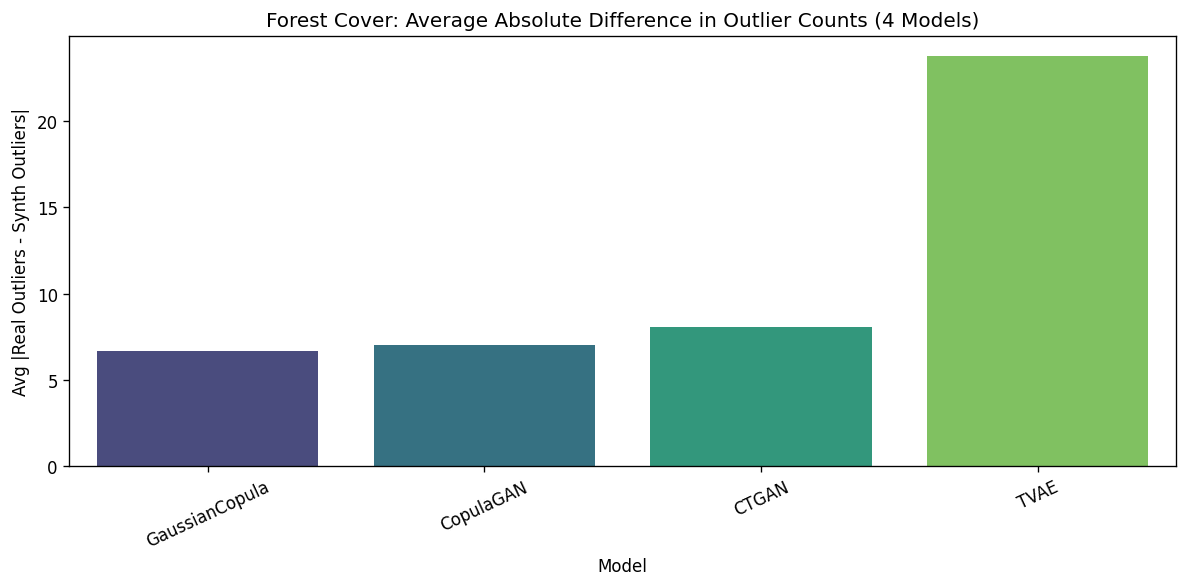

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to include all four models used in the evaluation
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Cover_Type"
real_df = covertype_data.copy() if 'covertype_data' in globals() else real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

# Handle NaN before outlier detection
real_df_clean = real_df[num_cols].fillna(real_df[num_cols].median())
real_outliers = {c: outlier_count_iqr(real_df_clean[c]) for c in num_cols}

for model in model_order:
    if model not in synthetic_outputs:
        continue

    synth_df = synthetic_outputs[model].copy()

    # Clean synthetic data and align columns
    synth_df_clean = synth_df[num_cols].fillna(synth_df[num_cols].median())
    synth_num_cols = [c for c in num_cols if c in synth_df_clean.columns]

    synth_outliers = {c: outlier_count_iqr(synth_df_clean[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(10, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis", hue="Model", legend=False)
plt.title("Forest Cover: Average Absolute Difference in Outlier Counts (4 Models)")
plt.xlabel("Model")
plt.ylabel("Avg |Real Outliers - Synth Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [73]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is not None and target_col in num_cols:
        num_cols.remove(target_col)

    # Handle NaN before normalization
    R_clean = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
    S_clean = synth_df[num_cols].fillna(synth_df[num_cols].median()).to_numpy(dtype=float)

    return normalize_rows(R_clean) @ normalize_rows(S_clean).T

# Configuration for the four models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Cover_Type"
real_df = covertype_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

cosine_results = {}
cosine_dfs = {}

# Normalize real matrix once
real_matrix = normalize_rows(real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"Warning: {model_name} not found in synthetic_outputs.")
        continue

    synth_df = synthetic_outputs[model_name].copy()

    # Clean and align columns
    synth_clean = synth_df[num_cols].fillna(synth_df[num_cols].median())
    print(f"Building cosine similarity for {model_name}...")

    synth_matrix = normalize_rows(synth_clean.to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    # Capture a 10x10 block for sample display
    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "Avg_Cosine": float(cosine_matrix.mean()),
        "Max_Cosine": float(cosine_matrix.max())
    }

    print(f"{model_name} cosine sample (first 10x10):\n", cosine_df.round(3), "\n")

# Display summary comparison
summary_cosine_df = pd.DataFrame(cosine_results).T.sort_values("Avg_Cosine", ascending=False)
display(summary_cosine_df)

Building cosine similarity for CTGAN...
CTGAN cosine sample (first 10x10):
         S1     S2     S3     S4     S5     S6     S7     S8     S9    S10
R1   0.663  0.941  0.992  0.906  0.990  0.866  0.983  0.919  0.773  0.971
R2   0.923  0.989  0.893  0.697  0.898  0.973  0.870  0.981  0.811  0.957
R3   0.821  0.958  0.856  0.615  0.836  0.915  0.916  0.872  0.963  0.889
R4   0.490  0.800  0.807  0.638  0.763  0.698  0.920  0.666  0.929  0.757
R5   0.573  0.788  0.713  0.471  0.664  0.711  0.848  0.634  0.980  0.697
R6   0.981  0.891  0.708  0.468  0.723  0.930  0.669  0.898  0.699  0.820
R7   0.450  0.825  0.914  0.835  0.887  0.712  0.971  0.741  0.814  0.842
R8   0.851  0.983  0.886  0.661  0.881  0.954  0.925  0.912  0.929  0.922
R9   0.965  0.935  0.742  0.463  0.753  0.964  0.764  0.880  0.860  0.834
R10  0.966  0.929  0.795  0.598  0.809  0.939  0.740  0.959  0.697  0.898 

Building cosine similarity for CopulaGAN...
CopulaGAN cosine sample (first 10x10):
         S1     S2     S3

,Avg_Cosine,Max_Cosine
TVAE,0.890054,0.999961
GaussianCopula,0.886180,0.999918
CTGAN,0.840794,0.999935
CopulaGAN,0.830781,0.999888


In [75]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    # Identify numeric columns for calculation
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "Cover_Type"
    if target_col in num_cols:
        num_cols.remove(target_col)

    # Handle potential missing values before matrix math
    R = real_data[num_cols].fillna(real_data[num_cols].median()).to_numpy(dtype=float)
    S = synthetic_data[num_cols].fillna(real_data[num_cols].median()).to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

# Ensure we use the correct global variables
real_df = covertype_data.copy()
# Use the four models identified in the summary
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
sim_results = {}

for name in model_order:
    if name not in synthetic_outputs:
        print(f"Skipping {name}: Data not found.")
        continue

    synth_df = synthetic_outputs[name].copy()

    # Compute similarity
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(real_df, synth_df)

    sim_results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "avg_best_sim": np.mean(best_sims)
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n--- {name} - Top 10 Real -> Synthetic Matchings ---")
    print(f"Average Best Cosine Similarity: {np.mean(best_sims):.4f}")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. Real[{i}] -> Synth[{best_indices[i]}] | Similarity: {best_sims[i]:.4f}")

# Quick Summary Table
summary_data = []
for name, res in sim_results.items():
    summary_data.append({"Model": name, "Avg Best Similarity": res['avg_best_sim']})

display(pd.DataFrame(summary_data).sort_values("Avg Best Similarity", ascending=False))


--- CTGAN - Top 10 Real -> Synthetic Matchings ---
Average Best Cosine Similarity: 0.9983
01. Real[531] -> Synth[790] | Similarity: 0.9999
02. Real[818] -> Synth[159] | Similarity: 0.9999
03. Real[582] -> Synth[528] | Similarity: 0.9999
04. Real[854] -> Synth[383] | Similarity: 0.9999
05. Real[928] -> Synth[614] | Similarity: 0.9999
06. Real[979] -> Synth[836] | Similarity: 0.9999
07. Real[191] -> Synth[296] | Similarity: 0.9999
08. Real[623] -> Synth[614] | Similarity: 0.9998
09. Real[725] -> Synth[894] | Similarity: 0.9998
10. Real[247] -> Synth[943] | Similarity: 0.9998

--- CopulaGAN - Top 10 Real -> Synthetic Matchings ---
Average Best Cosine Similarity: 0.9981
01. Real[574] -> Synth[454] | Similarity: 0.9999
02. Real[817] -> Synth[453] | Similarity: 0.9999
03. Real[870] -> Synth[780] | Similarity: 0.9998
04. Real[731] -> Synth[432] | Similarity: 0.9998
05. Real[557] -> Synth[366] | Similarity: 0.9998
06. Real[939] -> Synth[605] | Similarity: 0.9998
07. Real[142] -> Synth[829] | 

,Model,Avg Best Similarity
3,GaussianCopula,0.998769
2,TVAE,0.998477
0,CTGAN,0.998348
1,CopulaGAN,0.998122


In [76]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "Cover_Type"
    if target_col in num_cols:
        num_cols.remove(target_col)

    # Handle potential missing values and align columns
    R = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
    S = synth_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)

    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # Cost is 1 - similarity (minimizing cost matches most similar pairs)
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = covertype_data.copy()

# Updated to include all four models from the synthetic_outputs dictionary
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
results = {}

for name in model_order:
    if name not in synthetic_outputs:
        print(f"Skipping {name}: model results not found.")
        continue

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    synth_df = synthetic_outputs[name].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)


CTGAN: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9767

R929 <-> S615   cosine similarity = 0.9999
R192 <-> S297   cosine similarity = 0.9999
R864 <-> S503   cosine similarity = 0.9997
R581 <-> S883   cosine similarity = 0.9994
R763 <-> S83   cosine similarity = 0.9994
R403 <-> S837   cosine similarity = 0.9994
R692 <-> S538   cosine similarity = 0.9994
R751 <-> S756   cosine similarity = 0.9994
R841 <-> S478   cosine similarity = 0.9993
R953 <-> S588   cosine similarity = 0.9992

CopulaGAN: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9549

R772 <-> S514   cosine similarity = 0.9996
R721 <-> S491   cosine similarity = 0.9992
R558 <-> S49   cosine similarity = 0.9990
R550 <-> S762   cosine similarity = 0.9986
R40 <-> S132   cosine similarity = 0.9976
R743 <-> S193   cosine similarity = 0.9974
R863 <-> S549   cosine similarity = 0.9973
R660 <-> S946   cosine similarity = 0.9972
R744 <-> S5

,Model,Avg_Hungarian_Cosine
3,GaussianCopula,0.997299
2,TVAE,0.985911
0,CTGAN,0.976664
1,CopulaGAN,0.954908


In [77]:
pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.4 MB/s eta 0:00:00


In [78]:
import pandas as pd
import numpy as np

# Configuration
real_df = covertype_data.copy() if 'covertype_data' in globals() else data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# Correct target for Cover_Type dataset
target_col = "Cover_Type"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found.")

# UPDATED: Include all four models evaluated
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "CoverType_Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name]
        # Align columns to real_df for side-by-side view
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)

print(f"Saved: {output_file}")

,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
3,GaussianCopula,1000,0.997299,0.997970,0.956077,0.999918
2,TVAE,1000,0.985911,0.990131,0.932818,0.999950
0,CTGAN,1000,0.976664,0.980069,0.924371,0.999880
1,CopulaGAN,1000,0.954908,0.957362,0.880326,0.999627


Saved: CoverType_Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  

In [79]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "Group" if "Group" in data.columns else "Group"

data_numeric = data.select_dtypes(include=[np.number]).dropna().copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (55,), Inv_cov shape: (55, 55)


In [80]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# Configuration
target_col = "Cover_Type"
num_cols = covertype_data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# 1. Compute real distribution statistics
real_numeric = covertype_data[num_cols].fillna(covertype_data[num_cols].median()).to_numpy(dtype=float)
mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))  # Stabilize

# 2. Synthetic source detection
synth_source = synthetic_outputs if "synthetic_outputs" in globals() else synthetic_datasets

# 3. Models to evaluate
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
mahalanobis_results = {}

for name in model_order:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].fillna(covertype_data[num_cols].median()).copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # Compute Mahalanobis distances
        dists = [mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric]
        dists = np.array(dists)

        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source.")

# 4. Create summary table
if mahalanobis_results:
    summary_mahal = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

    summary_mahal.index.name = "Model"
    summary_mahal = summary_mahal.sort_values("mean_dist")

    print("\nMahalanobis distance to real distribution (lower is better):")
    display(summary_mahal)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")

✓ CTGAN: mean Mahalanobis = 388.355
✓ CopulaGAN: mean Mahalanobis = 392.259
✓ TVAE: mean Mahalanobis = 191.742
✓ GaussianCopula: mean Mahalanobis = 284.273

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,191.742439,167.053589,127.912685,3.158086,529.095735
GaussianCopula,284.272857,167.035021,227.833556,3.511615,1054.161499
CTGAN,388.355310,500.407310,257.390434,5.244701,1509.242743
CopulaGAN,392.259237,500.817897,242.343319,5.690313,1424.840746


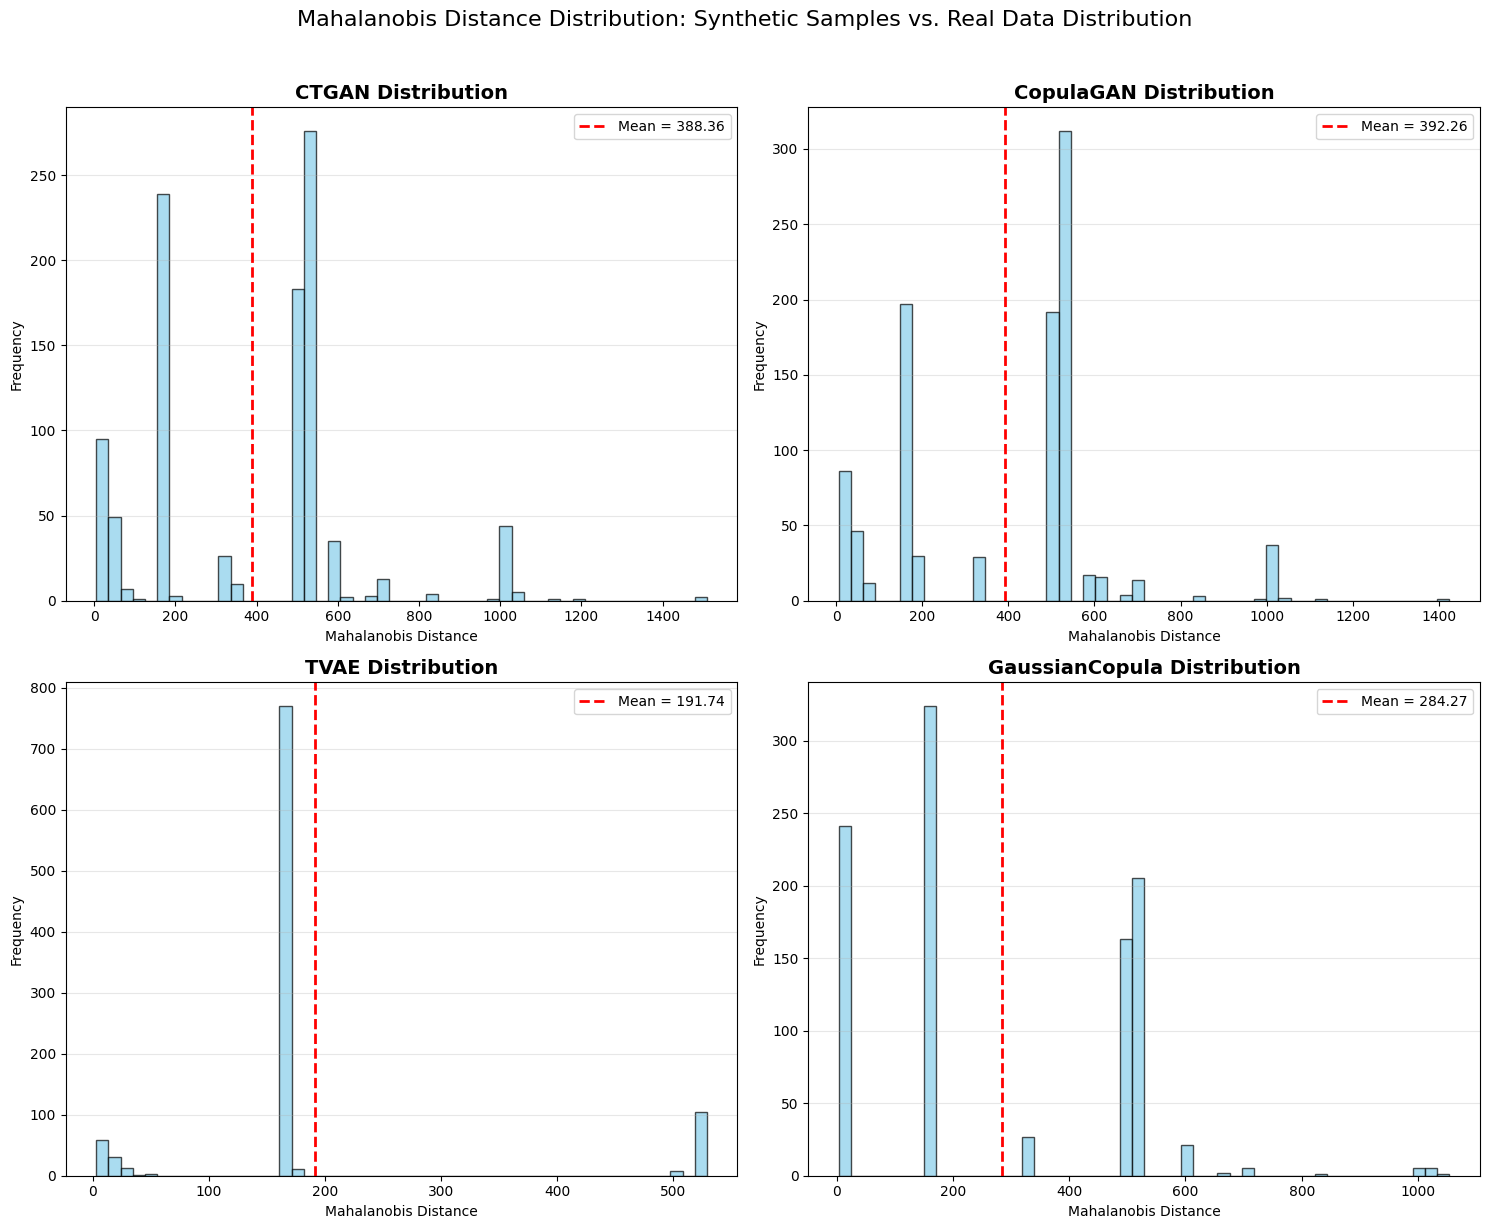

In [82]:
import os
import matplotlib.pyplot as plt

# Updated to a 2x2 grid to accommodate all 4 models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Iterating through all results in the mahalanobis_results dictionary
for i, (name, res) in enumerate(mahalanobis_results.items()):
    ax = axes[i]
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7, color='skyblue')
    ax.axvline(res["mean"], color="red", linestyle="--", linewidth=2, label=f"Mean = {res['mean']:.2f}")
    ax.set_title(f"{name} Distribution", fontsize=14, fontweight='bold')
    ax.set_xlabel("Mahalanobis Distance")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Hide any unused subplots if fewer than 4 models exist
for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis Distance Distribution: Synthetic Samples vs. Real Data Distribution", fontsize=16, y=1.02)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_covertype_all_models.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [83]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Configuration for Cover_Type dataset
target_col = "Cover_Type"
real_df = covertype_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# Clean data and compute covariance inverse
real_matrix = real_df[num_cols].fillna(real_df[num_cols].median()).to_numpy(dtype=float)
cov_real = np.cov(real_matrix, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}

# Reference the four models from the training pipeline
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
synth_source = synthetic_outputs

for name in model_order:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)

        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"\u2713 Processing {name} ({n_matches} matches)")

        # Hungarian matching
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "n_matches": n_matches
        }
    else:
        print(f"\u2717 {name} not found in synthetic outputs.")

# Summary table
if hungarian_results:
    hungarian_summary = pd.DataFrame(hungarian_results).T
    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("\nCover_Type Dataset: Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")

✓ Processing CTGAN (1000 matches)
✓ Processing CopulaGAN (1000 matches)
✓ Processing TVAE (1000 matches)
✓ Processing GaussianCopula (1000 matches)

Cover_Type Dataset: Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
TVAE,191.531331,167.055529,128.248035,529.081639,1000.0
GaussianCopula,283.631260,166.942082,228.583302,1054.341053,1000.0
CTGAN,387.931106,500.346874,257.879994,1509.555309,1000.0
CopulaGAN,391.836018,500.749317,242.880679,1424.752342,1000.0


In [84]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found.")

# Compute numeric features (exclude target)
target_col = "Cover_Type"
num_cols = covertype_data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# Clean real data and compute covariance inverse
real_matrix = covertype_data[num_cols].fillna(covertype_data[num_cols].median()).to_numpy(dtype=float)
cov_real = np.cov(real_matrix, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for name in model_order:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)

        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "n_matches": n_matches
        }
    else:
        print(f"✗ {name} not in synthetic source.")

# Summary table
if hungarian_results:
    hungarian_summary = pd.DataFrame(hungarian_results).T
    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("\nCover_Type Dataset: Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for evaluation.")

✓ Processing CTGAN: 1000 real vs 1000 synth → 1000 matches
✓ Processing CopulaGAN: 1000 real vs 1000 synth → 1000 matches
✓ Processing TVAE: 1000 real vs 1000 synth → 1000 matches
✓ Processing GaussianCopula: 1000 real vs 1000 synth → 1000 matches

Cover_Type Dataset: Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
TVAE,191.531331,167.055529,128.248035,529.081639,1000.0
GaussianCopula,283.631260,166.942082,228.583302,1054.341053,1000.0
CTGAN,387.931106,500.346874,257.879994,1509.555309,1000.0
CopulaGAN,391.836018,500.749317,242.880679,1424.752342,1000.0


In [85]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    # Efficient greedy matching using sorted distances if possible,
    # but sticking to the basic logic for clarity as per user context.
    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

# Source detection
synth_source = synthetic_outputs if "synthetic_outputs" in globals() else synthetic_datasets

# Configure columns for Cover_Type dataset
target_col = "Cover_Type"
num_cols = covertype_data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = covertype_data[num_cols].fillna(covertype_data[num_cols].median()).to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Evaluate all four models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for name in model_order:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name][num_cols].fillna(synth_source[name][num_cols].median())
        synth_numeric = synth_df.to_numpy(dtype=float)

        print(f"\u2713 Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")

        # Use existing inv_cov_real and pairwise_mahalanobis function
        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results (Mahalanobis)
        h_mean = hungarian_results[name]["mean_distance_per_match"]
        h_total = h_mean * hungarian_results[name]["n_matches"]

        comparison_rows.append({
            "Model": name,
            "Greedy Mean": mean_g,
            "Hungarian Mean": h_mean,
            "Mean Diff": mean_g - h_mean,
            "Greedy Total": total_g,
            "Hungarian Total": h_total
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"\u2717 Skipping {name} (missing data or Hungarian results)")

# Summary and Comparison
if comparison_rows:
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    print("\nComparison: Greedy vs Hungarian Matching (Mahalanobis Distance)")
    display(comparison_df.sort_values("Greedy Mean"))
else:
    print("No valid models matched.")

✓ Processing CTGAN: 1000 real vs 1000 synth
  Greedy mean: 387.9840 vs Hungarian: 387.9311 (diff: 0.0529)
✓ Processing CopulaGAN: 1000 real vs 1000 synth
  Greedy mean: 391.8780 vs Hungarian: 391.8360 (diff: 0.0420)
✓ Processing TVAE: 1000 real vs 1000 synth
  Greedy mean: 191.5824 vs Hungarian: 191.5313 (diff: 0.0510)
✓ Processing GaussianCopula: 1000 real vs 1000 synth
  Greedy mean: 283.6519 vs Hungarian: 283.6313 (diff: 0.0207)

Comparison: Greedy vs Hungarian Matching (Mahalanobis Distance)


,Greedy Mean,Hungarian Mean,Mean Diff,Greedy Total,Hungarian Total
Model,,,,,
TVAE,191.582355,191.531331,0.051024,191582.355005,191531.330654
GaussianCopula,283.651939,283.631260,0.020680,283651.939363,283631.259546
CTGAN,387.984007,387.931106,0.052901,387984.006935,387931.106242
CopulaGAN,391.878042,391.836018,0.042024,391878.042217,391836.018093


In [86]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Configuration for the Cover_Type dataset
real_df = covertype_data.copy() if 'covertype_data' in globals() else real_sample.copy()
target_col = "Cover_Type"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Evaluation for all four models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
hungarian_results = {}

# Use the synthetic_outputs dictionary containing the trained models
synth_source = synthetic_outputs if 'synthetic_outputs' in globals() else synthetic_datasets

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][feature_cols].copy()
        X_synth = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)

        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")

        D = cdist(X_real, X_synth, metric='mahalanobis', VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian matching
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        hungarian_results[model_name] = {
            "row_ind": row_ind,
            "col_ind": col_ind,
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(10, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
        print("-" * 40)
    else:
        print(f"✗ {model_name} not found in synthetic source.")

# Summary statistics comparison
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nCover_Type Dataset: Summary Mahalanobis distances (lower is better):")
    display(summary_stats)

✓ Processing CTGAN: 1000 real vs 1000 synth

CTGAN - Top 10 Hungarian matchings (lowest Mahalanobis distance):
01. R961 -> S853   distance = 3.4952
02. R651 -> S869   distance = 3.5391
03. R272 -> S484   distance = 4.3753
04. R365 -> S495   distance = 4.4798
05. R106 -> S991   distance = 4.8811
06. R137 -> S405   distance = 5.0381
07. R297 -> S277   distance = 5.5880
08. R264 -> S501   distance = 5.8311
09. R441 -> S915   distance = 5.8752
10. R149 -> S285   distance = 6.2502
----------------------------------------
✓ Processing CopulaGAN: 1000 real vs 1000 synth

CopulaGAN - Top 10 Hungarian matchings (lowest Mahalanobis distance):
01. R760 -> S392   distance = 3.2969
02. R274 -> S680   distance = 3.7534
03. R500 -> S481   distance = 3.9175
04. R112 -> S949   distance = 4.1685
05. R361 -> S669   distance = 4.7731
06. R927 -> S970   distance = 5.0245
07. R320 -> S501   distance = 5.0298
08. R285 -> S126   distance = 5.0645
09. R436 -> S35   distance = 5.1929
10. R795 -> S813   distance

,mean_dist,median_dist,min_dist
TVAE,191.531331,167.055529,1.532698
GaussianCopula,283.631260,166.942082,1.746265
CTGAN,387.931106,500.346874,3.495172
CopulaGAN,391.836018,500.749317,3.296896


In [87]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Direct synthetic source from the current pipeline
synth_source = synthetic_outputs

# Configuration for the Cover_Type dataset
real_df = covertype_data.copy()
target_col = "Cover_Type"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

# Clean data before matrix operations
X_real = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)

# Covariance with regularization (pinv for numerical stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Updated: Evaluate all four primary models
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][feature_cols].copy()
        X_synth = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)

        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")

        # Compute Mahalanobis distance matrix
        D = cdist(X_real, X_synth, metric='mahalanobis', VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian matching
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"\n  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"\n✗ {model_name} not found in synthetic_outputs.")


CTGAN: 1000 real vs 1000 synth
CTGAN - Hungarian mappings for R1 to R20:
R1 -> S523   distance = 342.3673
R2 -> S874   distance = 167.0004
R3 -> S300   distance = 500.1100
R4 -> S340   distance = 527.7202
R5 -> S136   distance = 40.8128
R6 -> S417   distance = 32.6007
R7 -> S441   distance = 529.3592
R8 -> S895   distance = 167.2198
R9 -> S973   distance = 529.8024
R10 -> S733   distance = 527.2134
R11 -> S18   distance = 601.3116
R12 -> S219   distance = 500.6400
R13 -> S238   distance = 527.2476
R14 -> S868   distance = 527.4085
R15 -> S882   distance = 502.8305
R16 -> S821   distance = 168.6666
R17 -> S460   distance = 500.8219
R18 -> S912   distance = 500.5957
R19 -> S693   distance = 171.3599
R20 -> S47   distance = 171.1726

  Summary: mean=387.9311, median=500.3469, min=3.4952

CopulaGAN: 1000 real vs 1000 synth
CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S523   distance = 602.9001
R2 -> S364   distance = 31.9075
R3 -> S494   distance = 707.4010
R4 -> S558   distance = 


Processing CTGAN: 1000 real vs 1000 synth


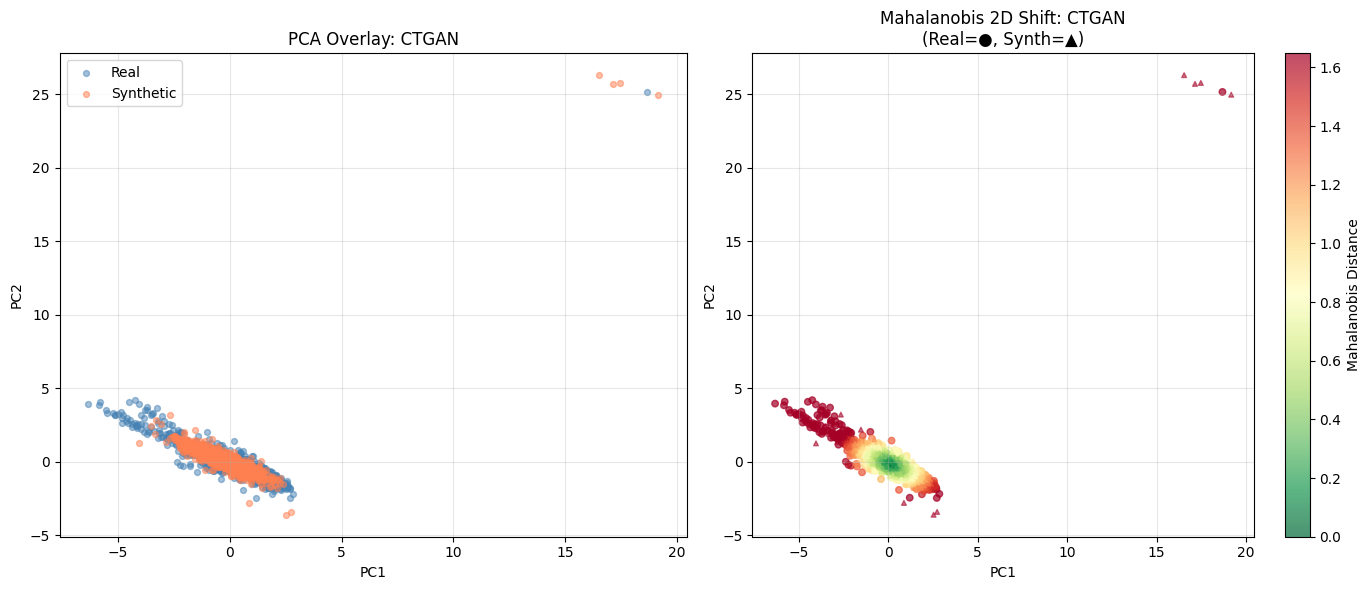

  Real Mean MD: 0.8941 | Synth Mean MD: 0.6850 | Delta: -0.2091

Processing CopulaGAN: 1000 real vs 1000 synth


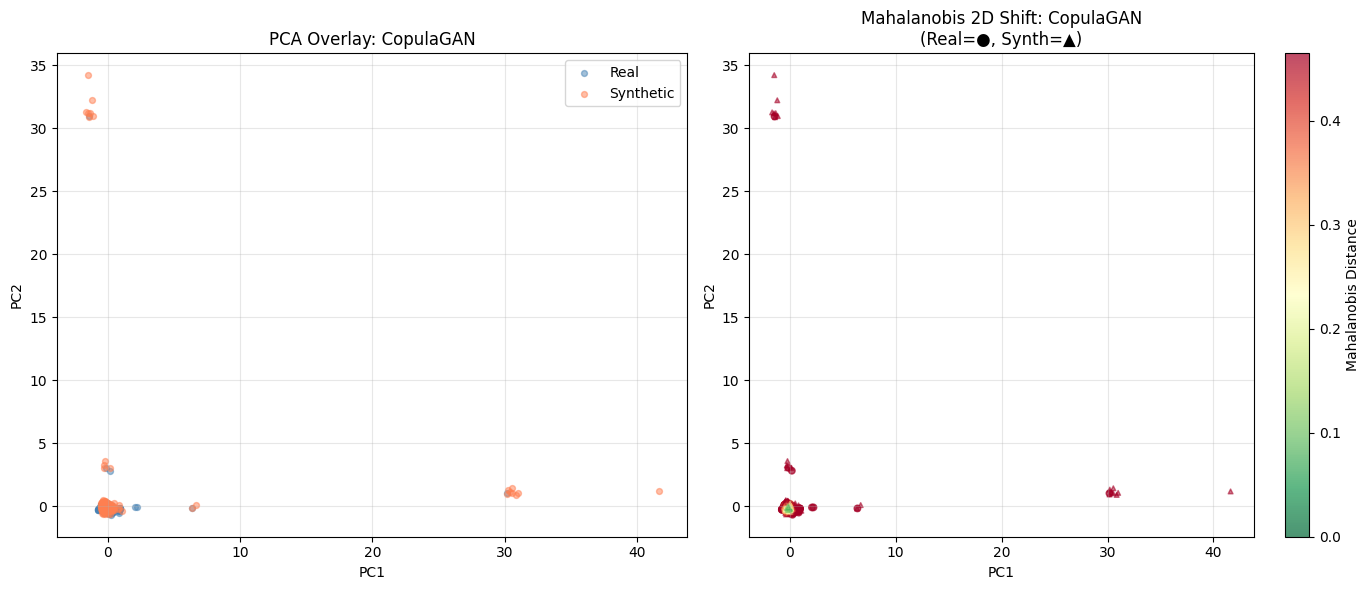

  Real Mean MD: 0.2803 | Synth Mean MD: 0.6690 | Delta: +0.3887

Processing TVAE: 1000 real vs 1000 synth


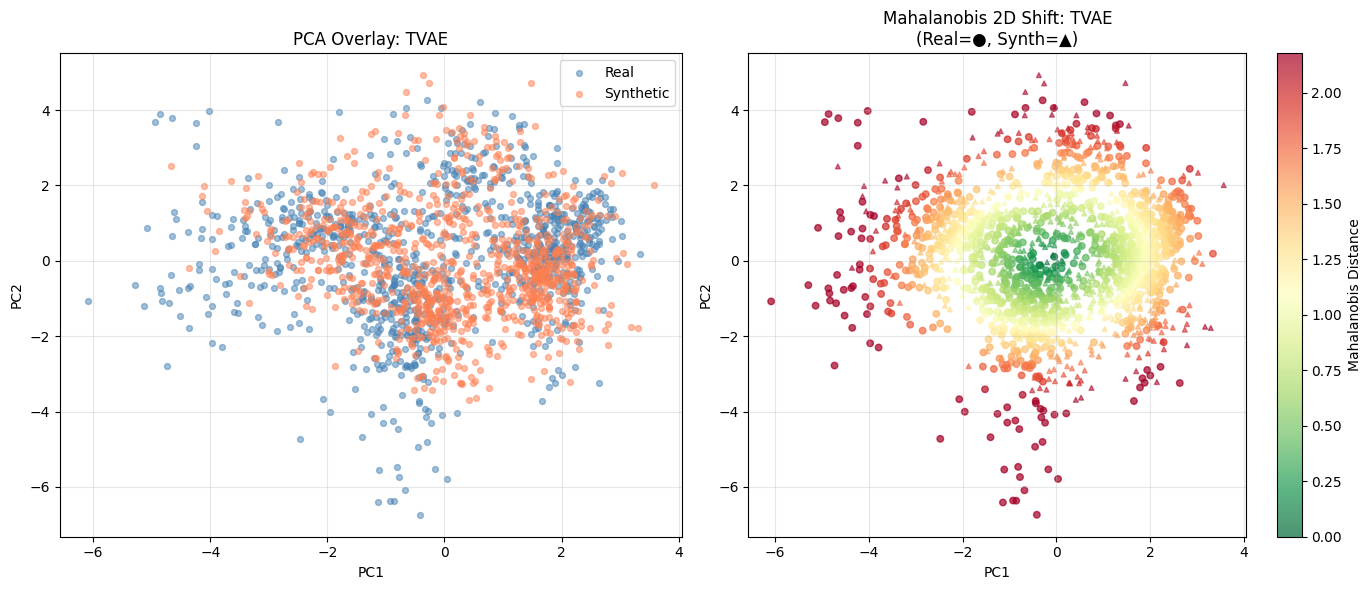

  Real Mean MD: 1.2838 | Synth Mean MD: 1.1120 | Delta: -0.1718

Processing GaussianCopula: 1000 real vs 1000 synth


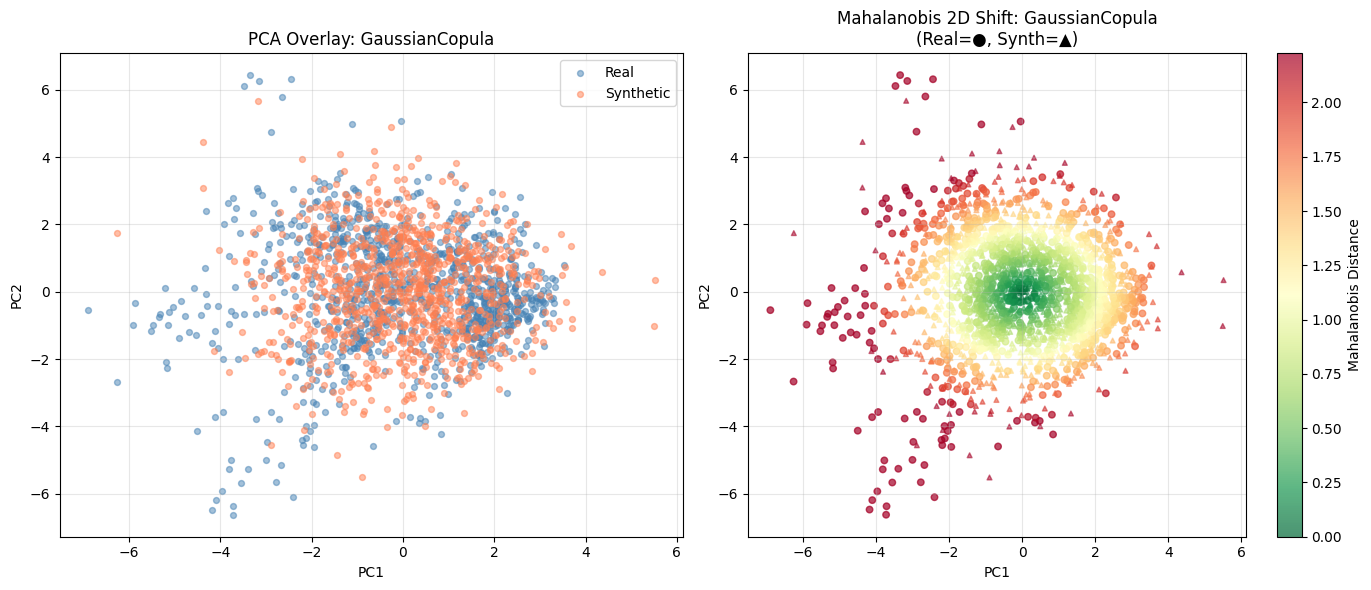

  Real Mean MD: 1.2398 | Synth Mean MD: 1.0789 | Delta: -0.1609

Summary Table: 2D Mahalanobis Distance Analysis (Lower Synth_Mean_MD_2D = Better Fidelity)


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta
1,CopulaGAN,0.280277,0.669010,0.388733
0,CTGAN,0.894134,0.684989,-0.209145
3,GaussianCopula,1.239795,1.078889,-0.160906
2,TVAE,1.283847,1.112009,-0.171837


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

synth_source = synthetic_outputs if 'synthetic_outputs' in globals() else synthetic_datasets
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = covertype_data.copy() if 'covertype_data' in globals() else real_sample.copy()
target_col = "Cover_Type"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_r = real_df[feature_cols].fillna(real_df[feature_cols].median()).to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        continue

    synth_df = synth_source[model_name][feature_cols].copy()
    X_s = synth_df.fillna(synth_df.median()).to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA Overlay: {model_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax)
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax)
    plt.colorbar(sc, ax=ax, label="Mahalanobis Distance")
    ax.set_title(f"Mahalanobis 2D Shift: {model_name}\n(Real=●, Synth=▲)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"{model_name} -> Real Mean MD: {d_r.mean():.4f} | Synth Mean MD: {d_s.mean():.4f}")

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [90]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "CoverType_Hungarian_Mahalanobis.xlsx"
):
    # Updated to include all four models from the current notebook pipeline
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name][num_cols].copy()
            synth_df = synth_df.fillna(synth_df.median())

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]
            matched_distances = hungarian_results[model_name]["dists"]

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                # Include first 10 numeric features for side-by-side comparison
                for c in num_cols[:10]:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run with Cover_Type pipeline variables ----
synth_source = synthetic_outputs
real_df = covertype_data.copy()
target_col = "Cover_Type"
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="CoverType_Hungarian_Mahalanobis.xlsx"
)

✓ Exported 1000 matches for CTGAN
✓ Exported 1000 matches for CopulaGAN
✓ Exported 1000 matches for TVAE
✓ Exported 1000 matches for GaussianCopula

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
2,TVAE,1000,191.531331,167.055529,128.248035,1.532698,529.081639
3,GaussianCopula,1000,283.631260,166.942082,228.583302,1.746265,1054.341053
0,CTGAN,1000,387.931106,500.346874,257.879994,3.495172,1509.555309
1,CopulaGAN,1000,391.836018,500.749317,242.880679,3.296896,1424.752342



✅ Excel file created: CoverType_Hungarian_Mahalanobis.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [91]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    # Ensure labels are within probability matrix bounds
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    # Combine losses: Real = 1, Synthetic = 0
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

# Configuration for the four primary models
target_col = "Cover_Type"
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns if c != target_col]
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Clean and encode real data
real_df = real_sample.copy()
real_df[feature_cols] = real_df[feature_cols].fillna(real_df[feature_cols].median())
le = LabelEncoder()
# Use the cleaning function defined in previous cells
y_real_encoded = le.fit_transform(clean_cover_type_labels(real_df[target_col]))

results = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not found in synthetic_outputs")
        continue

    print(f"\n{'='*50}")
    print(f"MIA for {model_name}")
    print(f"{'='*50}")

    synth_df = synthetic_outputs[model_name].copy()
    synth_df[feature_cols] = synth_df[feature_cols].fillna(real_df[feature_cols].median())

    # Encode synthetic labels (handle unseen classes if necessary)
    y_synth_raw = clean_cover_type_labels(synth_df[target_col])
    # Filter to only include classes present in training
    mask = y_synth_raw.isin(le.classes_)
    X_test = synth_df.loc[mask, feature_cols].to_numpy(dtype=float)
    y_test = le.transform(y_synth_raw[mask])

    X_train = real_df[feature_cols].to_numpy(dtype=float)
    y_train = y_real_encoded

    model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)

    metrics["Model"] = model_name
    results.append(metrics)

    print(f"  AUC: {metrics['AUC']:.4f}")
    print(f"  Advantage: {metrics['Advantage']:.4f}")
    print(f"  TPR@FPR=0.01: {metrics['TPR_at_FPR_001']:.4f}")

# Final Summary Table
if results:
    summary_df = pd.DataFrame(results).set_index("Model")
    print("\nMIA Results Summary (LOWER AUC = BETTER privacy):")
    display(summary_df.sort_values("AUC"))


MIA for CTGAN
  AUC: 0.8477
  Advantage: 0.5880
  TPR@FPR=0.01: 0.0530

MIA for CopulaGAN
  AUC: 0.7633
  Advantage: 0.4750
  TPR@FPR=0.01: 0.0390

MIA for TVAE
  AUC: 0.5823
  Advantage: 0.1280
  TPR@FPR=0.01: 0.0600

MIA for GaussianCopula
  AUC: 0.7041
  Advantage: 0.3500
  TPR@FPR=0.01: 0.0390

MIA Results Summary (LOWER AUC = BETTER privacy):


,AUC,Advantage,TPR_at_FPR_001
Model,,,
TVAE,0.582294,0.128,0.060
GaussianCopula,0.704147,0.350,0.039
CopulaGAN,0.763280,0.475,0.039
CTGAN,0.847734,0.588,0.053


In [92]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

# Configuration for Cover_Type dataset
target_col = "Cover_Type"
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns if c != target_col]
X_train = real_sample[feature_cols].fillna(real_sample[feature_cols].median()).to_numpy(dtype=float)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (Cover_Type Dataset)")
print("="*70)

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs, skipping")
        continue

    print(f"\n✓ Processing {model_name}...")
    X_test = synthetic_outputs[model_name][feature_cols].fillna(
        real_sample[feature_cols].median()
    ).to_numpy(dtype=float)

    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)

    print("\nMIA (Mahalanobis Distance) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic samples are from real distribution")
    print("• LOWER AUC = BETTER privacy protection")
    display(comparison_df)

    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉" if idx == 2 else "🎖️"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f} | Test_MD={row['Test_MD_Mean']:.3f}")
else:
    print("No valid models found.")

Mahalanobis MIA - Real vs Synthetic (Cover_Type Dataset)

✓ Processing CTGAN...

✓ Processing CopulaGAN...

✓ Processing TVAE...

✓ Processing GaussianCopula...

MIA (Mahalanobis Distance) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic samples are from real distribution
• LOWER AUC = BETTER privacy protection


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CopulaGAN,0.996018,0.944,0.875,6.033112,1356.973053
1,CTGAN,0.995706,0.946,0.875,6.033112,1368.504803
2,TVAE,0.984085,0.921,0.472,6.033112,1002.050132
3,GaussianCopula,0.950675,0.771,0.296,6.033112,1073.344533



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 GaussianCopula: AUC=0.951 | Test_MD=1073.345
🥈 TVAE: AUC=0.984 | Test_MD=1002.050
🥉 CTGAN: AUC=0.996 | Test_MD=1368.505
🎖️ CopulaGAN: AUC=0.996 | Test_MD=1356.973
